### John Frank
### Jinyi Zhang
### Elizabeth Quinlan
### Alexander Haken

# IMU Calibration and Characterization Lab

# Module A — Accelerometer Characterization

**Test A.1** Static Noise Test — `imuLogflattest.csv`  
**Test A.2** Gravity Vector Check (Six-Face Calibration) — `imuLog6bottom.csv`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

def load_imu(path):
    """Load IMU CSV, return dict of numpy arrays. Acceleration in milli-g."""
    with open(path, newline='') as f:
        f.readline()  # skip header
        rows = [line.strip().split(',') for line in f if line.strip()]
    t    = [datetime.strptime(r[0], '%Y/%m/%d %H:%M:%S.%f') for r in rows]
    dt   = np.array([(t[i] - t[0]).total_seconds() for i in range(len(t))])
    AccX = np.array([float(r[2]) for r in rows])
    AccY = np.array([float(r[3]) for r in rows])
    AccZ = np.array([float(r[4]) for r in rows])
    return {'t': t, 'dt': dt, 'AccX': AccX, 'AccY': AccY, 'AccZ': AccZ}

---
## Test A.1 — Static Noise Test

OLA placed flat and undisturbed. 



In [2]:
flat = load_imu('imuLogflattest.csv')

print(f"Flat-test samples : {len(flat['dt'])}")
print(f"Duration          : {flat['dt'][-1]:.1f} s")
fs = len(flat['dt']) / flat['dt'][-1]
print(f"Mean sample rate  : {fs:.2f} Hz")

Flat-test samples : 2839
Duration          : 257.6 s
Mean sample rate  : 11.02 Hz


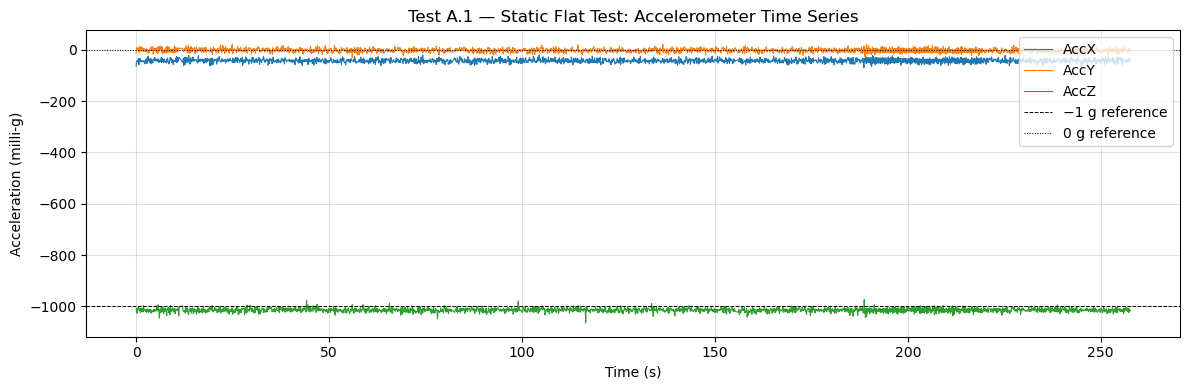

In [3]:
# ── Time-series plot of all three axes ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(flat['dt'], flat['AccX'], lw=0.8, label='AccX')
ax.plot(flat['dt'], flat['AccY'], lw=0.8, label='AccY')
ax.plot(flat['dt'], flat['AccZ'], lw=0.8, label='AccZ')

ax.axhline(-1000, color='k', ls='--', lw=0.7, label='−1 g reference')
ax.axhline(0,     color='k', ls=':',  lw=0.7, label='0 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.1 — Static Flat Test: Accelerometer Time Series')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Plot Z axis only for comparison and ease of viewing.

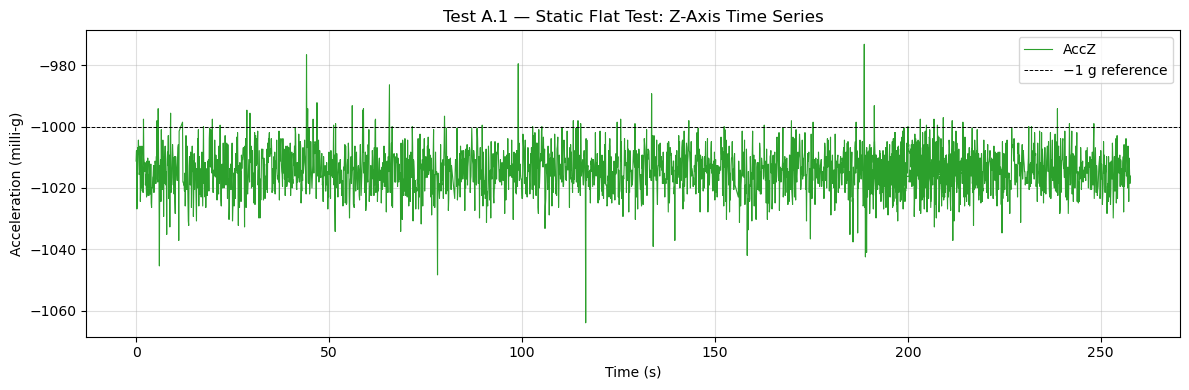

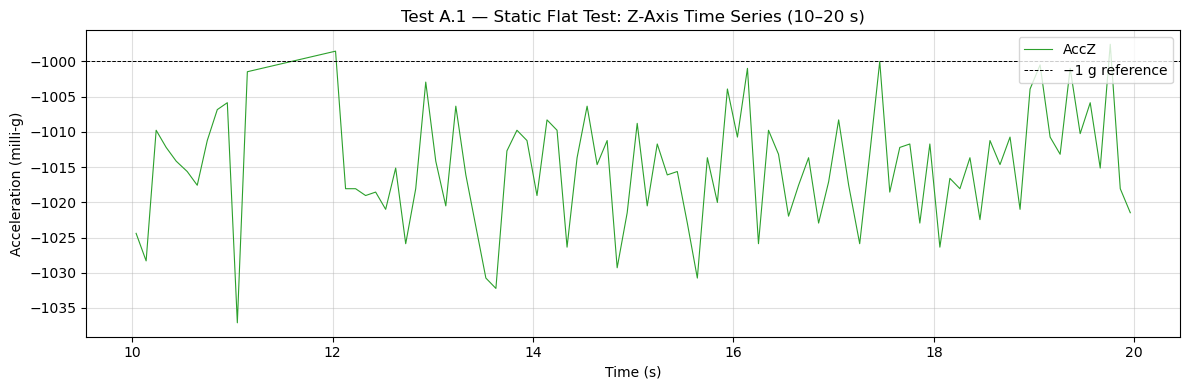

In [4]:
# ── Z-axis only time-series plot for Test A.1 ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(flat['dt'], flat['AccZ'], lw=0.8, color='tab:green', label='AccZ')

ax.axhline(-1000, color='k', ls='--', lw=0.7, label='−1 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.1 — Static Flat Test: Z-Axis Time Series')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ── Z-axis zoom: 10–20 s window - to better show frequency and noise ─────────────────────────────────────────────
mask_zoom = (flat['dt'] >= 10) & (flat['dt'] <= 20)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(flat['dt'][mask_zoom], flat['AccZ'][mask_zoom], lw=0.8, color='tab:green', label='AccZ')

ax.axhline(-1000, color='k', ls='--', lw=0.7, label='−1 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.1 — Static Flat Test: Z-Axis Time Series (10–20 s)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

AccX: measured RMS = 6.8637 mg  |  expected = 0.5399 mg  |  ratio = 12.71
AccY: measured RMS = 6.7508 mg  |  expected = 0.5399 mg  |  ratio = 12.50
AccZ: measured RMS = 7.1196 mg  |  expected = 0.5399 mg  |  ratio = 13.19


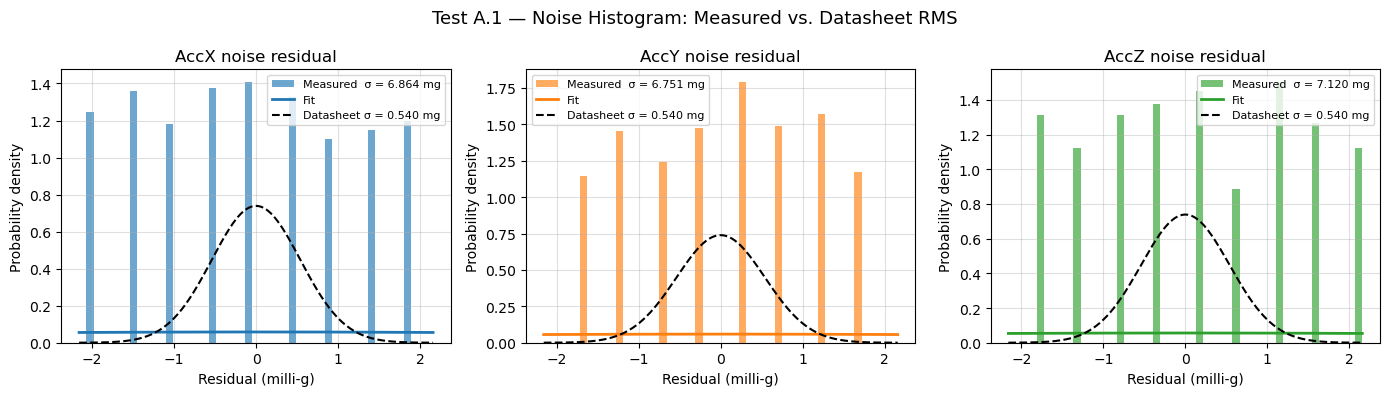

In [5]:
# ── Noise histogram with expected vs. measured RMS ───────────────────────────
# Remove the DC (mean) component so only the noise residual remains.
NOISE_DENSITY = 0.230   # mg/√Hz  (230 µg/√Hz converted to mg)
B             = fs / 2   # effective bandwidth (Hz)
sigma_expected = NOISE_DENSITY * np.sqrt(B)   # mg

axes_labels = ['X', 'Y', 'Z']
axes_data   = [flat['AccX'], flat['AccY'], flat['AccZ']]
colors      = ['tab:blue', 'tab:orange', 'tab:green']

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i, (lbl, data, col) in enumerate(zip(axes_labels, axes_data, colors)):
    residual = data - np.mean(data)
    sigma_meas = np.std(residual)

    bins  = np.linspace(-4 * sigma_expected, 4 * sigma_expected, 50)
    axs[i].hist(residual, bins=bins, color=col, alpha=0.65, density=True,
                label=f'Measured  σ = {sigma_meas:.3f} mg')

    x_gauss = np.linspace(bins[0], bins[-1], 300)
    gauss_meas    = (1/(sigma_meas    * np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_meas   )**2)
    gauss_expected= (1/(sigma_expected* np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_expected)**2)

    axs[i].plot(x_gauss, gauss_meas,     col,  lw=2, label='Fit')
    axs[i].plot(x_gauss, gauss_expected, 'k--', lw=1.5,
                label=f'Datasheet σ = {sigma_expected:.3f} mg')

    axs[i].set_title(f'Acc{lbl} noise residual')
    axs[i].set_xlabel('Residual (milli-g)')
    axs[i].set_ylabel('Probability density')
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.4)
    print(f'Acc{lbl}: measured RMS = {sigma_meas:.4f} mg  |  '
          f'expected = {sigma_expected:.4f} mg  |  '
          f'ratio = {sigma_meas/sigma_expected:.2f}')

fig.suptitle('Test A.1 — Noise Histogram: Measured vs. Datasheet RMS', fontsize=13)
plt.tight_layout()
plt.show()


# Static Accelerometer Test — Z-Up Orientation Analysis

---

## 1. Expected Values per Axis & Datasheet Zero-g Output

With the sensor in **Z-up** orientation, gravity ($g \approx 9.81\, \text{m/s}^2$) projects
entirely onto the Z-axis. The expected ideal readings are:

| Axis | Expected Output | Reason |
|------|----------------|--------|
| X    | 0.000 g        | Perpendicular to gravity |
| Y    | 0.000 g        | Perpendicular to gravity |
| Z    | +1.000 g       | Aligned with gravity, positive up convention |

**At rest the Z-axis reads ≈ −1 g (specific force = table normal force)  
while X and Y read ≈ 0 g. The data sheet refers to the steady state z-axis as positive (1)g, This means we had the sensor orriented upside down and the positive zaxis pointed down with gravity.

- The zero-g offset is the output when **no acceleration** is applied to that axis
- zero-g offset tolerance: $\pm 50\, \text{mg}$
  -> This means even a "perfect" sensor at rest on X/Y may read $ 1 \pm 0.050\,g $
  before calibration ( which ours does.)

> **Key distinction:** The zero-g output is the *bias* $b$ in your calibration model.
> In part 2: The corrected reading subtracts this: $a_{corrected} = (a_{raw} - b)/s$

---

## 2. Quantifying Noise — The Right Statistic and Why

**Use the standard deviation ($\sigma$), not the peak-to-peak range.**

$$\sigma = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N}(a_i - \bar{a})^2}$$

| Statistic | Use for | Problem if used for noise |
|-----------|---------|--------------------------|
| Mean $\bar{a}$ | Estimating bias | Tells you *offset*, not spread |
| Std Dev $\sigma$ | **Noise quantification** ✓ | None — this is the right choice |
| Peak-to-peak | Worst-case bounds | Sensitive to outliers, grows with $N$ |
| RMS | Total signal power | Equals $\sigma$ only when mean $\approx 0$ |

**Why $\sigma$?**
- MEMS accelerometer noise is well-modeled as **white Gaussian noise** in the measurement band
- $\sigma$ is the natural parameter of a Gaussian distribution
- It is stable and converges as $N$ increases, unlike peak-to-peak
- It directly maps to the datasheet **noise spectral density** specification

---

## 3. Datasheet Noise Prediction vs. Your Measurement

**From the noise spectral density (NSD) in Table 2:**

The datasheet gives noise density in units of $\mu g / \sqrt{\text{Hz}}$.
The predicted RMS noise over a bandwidth $f_{BW}$ is:

$$\sigma_{predicted} = NSD \times \sqrt{f_{BW}}$$

For a digital sensor sampled at $f_s$, the effective noise bandwidth is:

$$f_{BW} = \frac{f_s}{2} \quad \text{(Nyquist, for a flat response)}$$

So the full prediction is:

$$\boxed{\sigma_{predicted} = NSD \times \sqrt{\frac{f_s}{2}}}$$



| Parameter | Symbol | Example Value |
|-----------|--------|--------------|
| Noise spectral density | $NSD$ | $230\, \mu g/\sqrt{\text{Hz}}$ |
| Sample rate | $f_s$ | $10\, \text{Hz}$ |
| Bandwidth | $f_{BW}$ | $5\, \text{Hz}$ |
| Predicted RMS noise | $\sigma_{predicted}$ | $230 \times \sqrt{5} \approx 514\, \mu g$ |

**Comparing to your measurement:**

$$\text{Ratio} = \frac{\sigma_{measured}}{\sigma_{predicted}}$$

- Ratio $\approx 1.0$: sensor behaves as datasheet predicts ✓
- Ratio $> 1.5$: excess noise — check for vibration, EMI, power supply noise, or
  insufficient averaging
- Ratio $< 0.7$: your filter or ODR setting may be reducing bandwidth below $f_s/2$


** Our Data found: $$12 \approx \frac{\sigma_{measured}}{\sigma_{predicted}}$$ 
 Noise values of approximately $6-7 mg$ were found. This means that for some reason our sensors was exposed to background vibrations well above what can be considered noise.

---

## 4. OLA Axis Orientation When Flat & Sign/Magnitude Implications

**OLA = Output Limiting Axis** (the axis aligned with gravity in a given orientation).

When the sensor is **lying flat** (Z-up):

$$\text{OLA} = \textbf{Z-axis}$$

This is because:
- The Z-axis is **perpendicular to the PCB plane** in a standard MEMS footprint
- Gravity ($-g$ in the inertial frame, or $+g$ in the sensor frame for Z-up) projects
  entirely onto Z
- X and Y are in the horizontal plane — orthogonal to $\vec{g}$

**Sign and magnitude implications:**

$$a_Z^{raw} = s_Z \cdot (+1\,g) + b_Z$$

| Effect | Impact on reading |
|--------|------------------|
| Positive $b_Z$ | Shifts Z reading above +1 g |
| Negative $b_Z$ | Shifts Z reading below +1 g |
| $s_Z > 1$ | Z reading magnitude inflated |
| $s_Z < 1$ | Z reading magnitude suppressed |
| Cross-axis coupling | X, Y show small non-zero values even though gravity is purely on Z |

**Physical interpretation:**
- If Z reads **+1 g**: sensor defines Z-up as positive (right-hand convention, common)
- If Z reads **−1 g** when physically Z-up: sensor uses **Z-down positive** convention —
  check your datasheet orientation diagram
- X and Y deviations from 0 g when flat directly reveal your **cross-axis coupling**
  and **zero-g bias** on those axes without needing to flip the sensor


---
## Test A.2 — Gravity Vector Check (Six-Face Calibration)

The OLA is rotated through all six face-down orientations. For each axis the calibration model is:

$$a_\text{corrected} = \frac{a_\text{raw} - b}{s}$$

With two opposing orientations on axis $i$ (raw mean when +1 g expected = $p_i$; when −1 g expected = $n_i$):

$$b_i = \frac{p_i + n_i}{2}, \qquad s_i = \frac{p_i - n_i}{2}$$

**Variable definitions:**

| Symbol | Description | Units |
|--------|-------------|-------|
| $a_\text{corrected}$ | Calibration-corrected acceleration output | milli-g |
| $a_\text{raw}$ | Raw (uncorrected) accelerometer reading | milli-g |
| $b_i$ | Bias offset for axis $i$ — midpoint error between the two opposing readings | milli-g |
| $s_i$ | Scale factor for axis $i$ — half the span between the two opposing readings (ideal = 1000 mg/g) | milli-g/g |
| $p_i$ | Mean raw reading on axis $i$ when +1 g is expected (positive face down) | milli-g |
| $n_i$ | Mean raw reading on axis $i$ when −1 g is expected (negative face down) | milli-g |
| $i$ | Axis index: X, Y, or Z | — |

Faces are detected automatically using a threshold on the dominant axis.

In [6]:
six = load_imu('imuLog6bottom.csv')

print(f"Six-face samples  : {len(six['dt'])}")
print(f"Duration          : {six['dt'][-1]:.1f} s")

Six-face samples  : 833
Duration          : 84.2 s


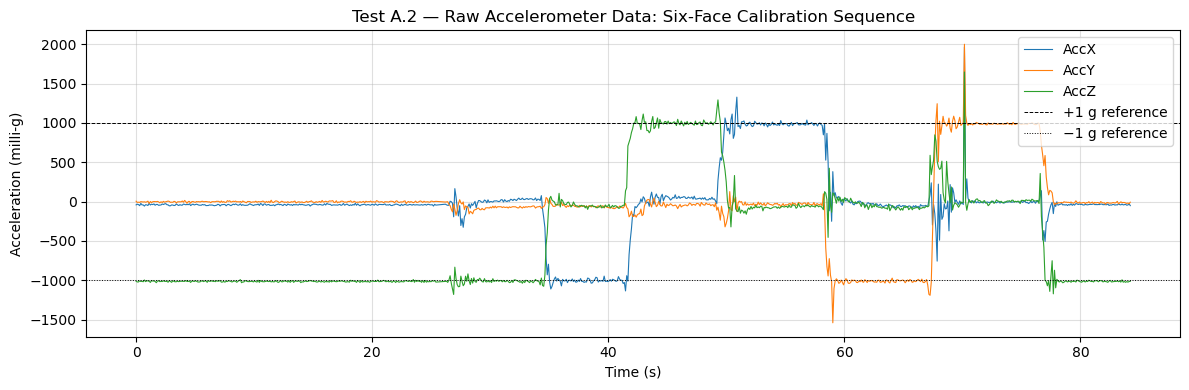

In [7]:
# ── Raw time-series plot of six-face data ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(six['dt'], six['AccX'], lw=0.8, label='AccX')
ax.plot(six['dt'], six['AccY'], lw=0.8, label='AccY')
ax.plot(six['dt'], six['AccZ'], lw=0.8, label='AccZ')

ax.axhline( 1000, color='k', ls='--', lw=0.7, label='+1 g reference')
ax.axhline(-1000, color='k', ls=':',  lw=0.7, label='−1 g reference')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (milli-g)')
ax.set_title('Test A.2 — Raw Accelerometer Data: Six-Face Calibration Sequence')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [8]:
# ── Detect face orientations ─────────────────────────────────────────────────
THRESHOLD = 800  # milli-g  — axis reading above this magnitude → dominant axis

AX = six['AccX']
AY = six['AccY']
AZ = six['AccZ']

# Assign a label to every sample
face_label = np.full(len(AX), '', dtype=object)
face_label[( AZ >  THRESHOLD)] = '+Z'
face_label[( AZ < -THRESHOLD)] = '-Z'
face_label[( AX >  THRESHOLD)] = '+X'
face_label[( AX < -THRESHOLD)] = '-X'
face_label[( AY >  THRESHOLD)] = '+Y'
face_label[( AY < -THRESHOLD)] = '-Y'

for face in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    n = np.sum(face_label == face)
    print(f"{face}: {n} samples ({n/len(AX)*100:.1f} %)")

unclassified = np.sum(face_label == '')
print(f"Unclassified (transition): {unclassified} samples")

+X: 86 samples (10.3 %)
-X: 68 samples (8.2 %)
+Y: 88 samples (10.6 %)
-Y: 88 samples (10.6 %)
+Z: 78 samples (9.4 %)
-Z: 411 samples (49.3 %)
Unclassified (transition): 14 samples


In [9]:
# ── Compute bias and scale factor per axis ───────────────────────────────────
def face_mean(axis_data, face_label, face):
    mask = face_label == face
    if mask.sum() == 0:
        raise ValueError(f"No samples found for face '{face}' — adjust THRESHOLD or check data")
    return np.mean(axis_data[mask])

results = {}
for axis, data in [('X', AX), ('Y', AY), ('Z', AZ)]:
    pos = face_mean(data, face_label, f'+{axis}')
    neg = face_mean(data, face_label, f'-{axis}')
    b = (pos + neg) / 2          # bias  (milli-g)
    s = (pos - neg) / 2          # scale (milli-g per g, ideal = 1000)
    results[axis] = {'pos': pos, 'neg': neg, 'bias': b, 'scale': s}
    print(f"Axis {axis}: +face={pos:+.2f} mg  -face={neg:+.2f} mg  "
          f"bias={b:+.2f} mg  scale={s:.2f} mg/g")

# Extract calibration parameters
bx, sx  = results['X']['bias'], results['X']['scale']
by_, sy = results['Y']['bias'], results['Y']['scale']
bz, sz  = results['Z']['bias'], results['Z']['scale']

# ── Per-face norm analysis ────────────────────────────────────────────────────
G = 1000.0  # 1 g in milli-g

print()
print("─" * 66)
print(f"{'Face':<6} {'‖a_raw‖ (mg)':>14} {'‖a_corr‖ (mg)':>15} {'|‖a_corr‖ − 1g| (mg)':>22}")
print("─" * 66)

for face in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    mask = face_label == face

    # Mean raw vector for this face
    mx = np.mean(AX[mask])
    my = np.mean(AY[mask])
    mz = np.mean(AZ[mask])
    norm_raw = np.sqrt(mx**2 + my**2 + mz**2)

    # Apply bias and scale correction (output in milli-g)
    mx_c = (mx - bx) / sx * 1000
    my_c = (my - by_) / sy * 1000
    mz_c = (mz - bz) / sz * 1000
    norm_corr = np.sqrt(mx_c**2 + my_c**2 + mz_c**2)

    residual = abs(norm_corr - G)

    print(f"{face:<6} {norm_raw:>14.2f} {norm_corr:>15.2f} {residual:>22.2f}")

print("─" * 66)

Axis X: +face=+983.60 mg  -face=-1007.02 mg  bias=-11.71 mg  scale=995.31 mg/g
Axis Y: +face=+1003.50 mg  -face=-1019.95 mg  bias=-8.23 mg  scale=1011.72 mg/g
Axis Z: +face=+995.65 mg  -face=-1014.72 mg  bias=-9.54 mg  scale=1005.19 mg/g

──────────────────────────────────────────────────────────────────
Face     ‖a_raw‖ (mg)   ‖a_corr‖ (mg)   |‖a_corr‖ − 1g| (mg)
──────────────────────────────────────────────────────────────────
+X             985.87         1001.45                   1.45
-X            1009.20         1001.45                   1.45
+Y            1005.38         1002.54                   2.54
-Y            1020.74         1000.45                   0.45
+Z             997.39         1001.72                   1.72
-Z            1015.59         1000.41                   0.41
──────────────────────────────────────────────────────────────────


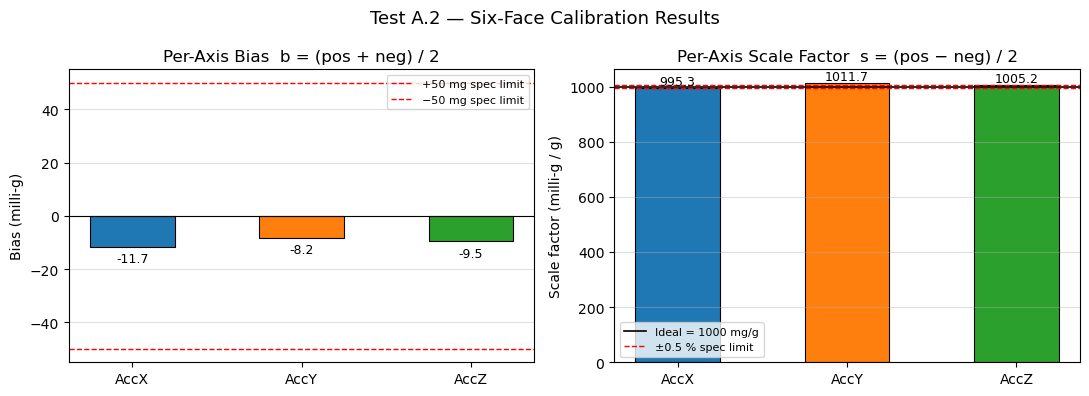

In [10]:
# ── Six-face bar chart: per-axis bias and scale factor ───────────────────────
axes_labels = ['X', 'Y', 'Z']
biases      = [results[a]['bias']  for a in axes_labels]
scales      = [results[a]['scale'] for a in axes_labels]

x = np.arange(3)
width = 0.5

fig, (ax_b, ax_s) = plt.subplots(1, 2, figsize=(11, 4))

# Bias
bars_b = ax_b.bar(x, biases, width, color=['tab:blue','tab:orange','tab:green'],
                  edgecolor='k', linewidth=0.8)
ax_b.axhline(0, color='k', lw=0.8)
ax_b.axhline( 50, color='r', ls='--', lw=1.0, label='+50 mg spec limit')
ax_b.axhline(-50, color='r', ls='--', lw=1.0, label='−50 mg spec limit')
ax_b.set_xticks(x); ax_b.set_xticklabels([f'Acc{a}' for a in axes_labels])
ax_b.set_ylabel('Bias (milli-g)')
ax_b.set_title('Per-Axis Bias  b = (pos + neg) / 2')
ax_b.legend(fontsize=8)
ax_b.grid(True, axis='y', alpha=0.4)
for bar, val in zip(bars_b, biases):
    ax_b.text(bar.get_x() + bar.get_width()/2, val + np.sign(val)*2,
              f'{val:+.1f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=9)

# Scale factor
bars_s = ax_s.bar(x, scales, width, color=['tab:blue','tab:orange','tab:green'],
                  edgecolor='k', linewidth=0.8)
ax_s.axhline(1000, color='k', ls='-',  lw=1.2, label='Ideal = 1000 mg/g')
ax_s.axhline(1005, color='r', ls='--', lw=1.0, label='±0.5 % spec limit')
ax_s.axhline( 995, color='r', ls='--', lw=1.0)
ax_s.set_xticks(x); ax_s.set_xticklabels([f'Acc{a}' for a in axes_labels])
ax_s.set_ylabel('Scale factor (milli-g / g)')
ax_s.set_title('Per-Axis Scale Factor  s = (pos − neg) / 2')
ax_s.legend(fontsize=8)
ax_s.grid(True, axis='y', alpha=0.4)
for bar, val in zip(bars_s, scales):
    ax_s.text(bar.get_x() + bar.get_width()/2, val + 1,
              f'{val:.1f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Test A.2 — Six-Face Calibration Results', fontsize=13)
plt.tight_layout()
plt.show()

Raw magnitude :  mean = 1014.18 mg   std = 98.40 mg
Cal magnitude :  mean = 1005.55 mg   std = 98.13 mg
Target = 1000.00 mg


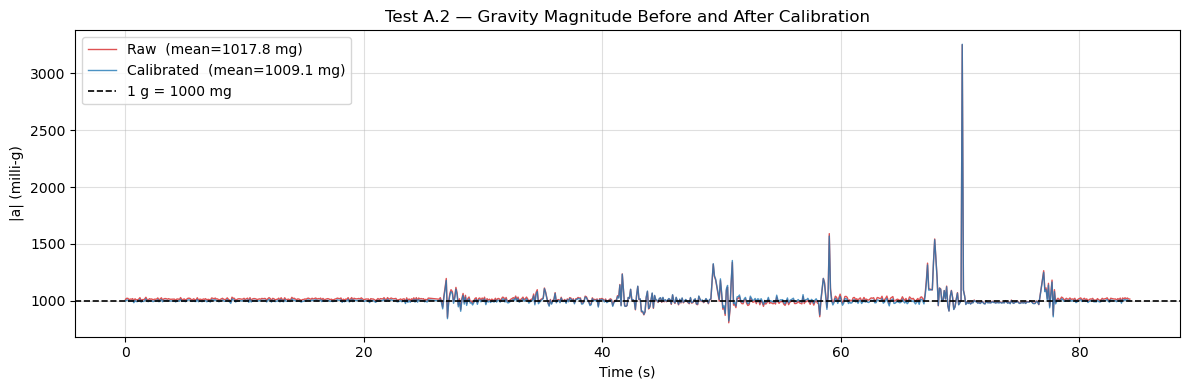

In [11]:
# ── Gravity magnitude before and after calibration correction ────────────────
bx, sx = results['X']['bias'], results['X']['scale']
by_, sy = results['Y']['bias'], results['Y']['scale']
bz, sz = results['Z']['bias'], results['Z']['scale']

# Raw magnitude
mag_raw = np.sqrt(AX**2 + AY**2 + AZ**2)

# Corrected axes (output in milli-g, 1 g = 1000 mg)
AX_c = (AX - bx) / sx * 1000
AY_c = (AY - by_) / sy * 1000
AZ_c = (AZ - bz) / sz * 1000
mag_cal = np.sqrt(AX_c**2 + AY_c**2 + AZ_c**2)

print(f"Raw magnitude :  mean = {np.mean(mag_raw):.2f} mg   std = {np.std(mag_raw):.2f} mg")
print(f"Cal magnitude :  mean = {np.mean(mag_cal):.2f} mg   std = {np.std(mag_cal):.2f} mg")
print(f"Target = 1000.00 mg")

fig, ax = plt.subplots(figsize=(12, 4))

# Use only classified samples for clarity
classified = face_label != ''
ax.plot(six['dt'][classified], mag_raw[classified],
        color='tab:red',  lw=1.0, alpha=0.8, label=f'Raw  (mean={np.mean(mag_raw[classified]):.1f} mg)')
ax.plot(six['dt'][classified], mag_cal[classified],
        color='tab:blue', lw=1.0, alpha=0.8, label=f'Calibrated  (mean={np.mean(mag_cal[classified]):.1f} mg)')

ax.axhline(1000, color='k', ls='--', lw=1.2, label='1 g = 1000 mg')

ax.set_xlabel('Time (s)')
ax.set_ylabel('|a| (milli-g)')
ax.set_title('Test A.2 — Gravity Magnitude Before and After Calibration')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

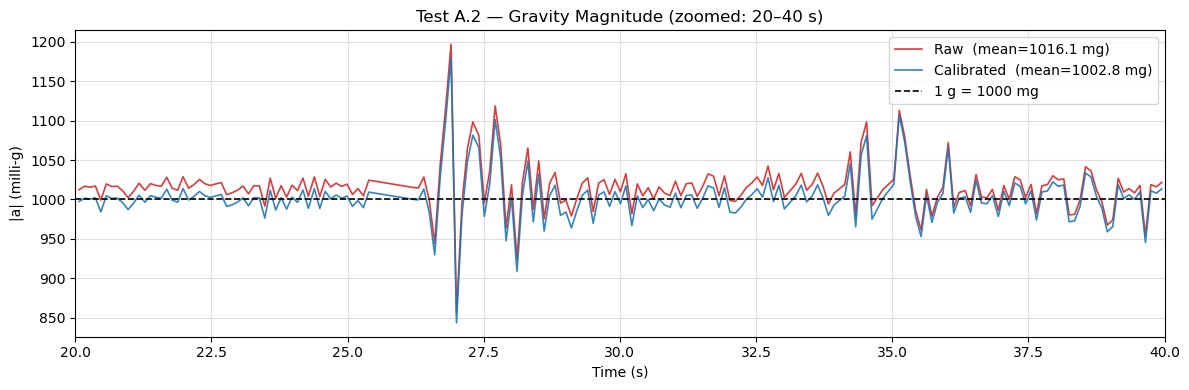

In [12]:
# ── Zoomed view: 20–40 s window ──────────────────────────────────────────────
t_zoom = six['dt'][classified]
mask_zoom = (t_zoom >= 20) & (t_zoom <= 40)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t_zoom[mask_zoom], mag_raw[classified][mask_zoom],
        color='tab:red',  lw=1.2, alpha=0.9,
        label=f'Raw  (mean={np.mean(mag_raw[classified][mask_zoom]):.1f} mg)')
ax.plot(t_zoom[mask_zoom], mag_cal[classified][mask_zoom],
        color='tab:blue', lw=1.2, alpha=0.9,
        label=f'Calibrated  (mean={np.mean(mag_cal[classified][mask_zoom]):.1f} mg)')

ax.axhline(1000, color='k', ls='--', lw=1.2, label='1 g = 1000 mg')

ax.set_xlim(20, 40)
ax.set_xlabel('Time (s)')
ax.set_ylabel('|a| (milli-g)')
ax.set_title('Test A.2 — Gravity Magnitude (zoomed: 20–40 s)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Accelerometer 6-Position Calibration Analysis

---

## 1. Solving for Bias *b* and Scale Factor *s* from Two Opposing Orientations

When you place the sensor with **+Z up**, gravity projects fully onto the Z-axis:

$$a_{raw}^+ \approx +\frac{g}{s} + b$$

When you flip to **−Z up**:

$$a_{raw}^- \approx -\frac{g}{s} + b$$

These are two equations in two unknowns. Solving them:

**Bias** (average of the two raw readings — gravity cancels out):

$$b = \frac{a_{raw}^+ + a_{raw}^-}{2}$$

**Scale factor** (half the difference, normalized by *g*):

$$s = \frac{a_{raw}^+ - a_{raw}^-}{2g}$$

Then your corrected reading is:

$$a_{corrected} = \frac{a_{raw} - b}{s}$$

This works because the two orientations create a symmetric bracket around the true ±g values —
bias shifts both readings equally, while scale factor stretches them symmetrically.

---

## 2. What Should ‖a‖ Equal, and Does Your Data Satisfy It?

In every static orientation, only gravity acts on the sensor, so the **true total acceleration
magnitude must equal 1 g** regardless of orientation:

$$\|a\| = \sqrt{a_x^2 + a_y^2 + a_z^2} = 1\,g \approx 9.81\,\text{m/s}^2$$

YES, our data does satisfy this metric each corrected values is with in $.5\%$. 
---

## 3. Cross-Axis Coupling in 6-Face Data

Cross-axis coupling means that when gravity is along Z, you also see a small spurious signal
on X and Y — due to sensor misalignment or crosstalk in the MEMS element.

**What it looks like in the data:**

When Z-axis is fully stimulated (+Z up), ideally:

| Axis | Expected | Actual (example) |
|------|----------|------------------|
| X    | 0.000 g  | +0.012 g         |
| Y    | 0.000 g  | −0.008 g         |
| Z    | +1.000 g | +0.998 g         |

Those non-zero X and Y readings *are* the cross-axis coupling.

**Estimating coupling coefficients:**

The full model is a 3×3 matrix equation:

$$\vec{a}_{corrected} = S^{-1}(\vec{a}_{raw} - \vec{b})$$

where $S$ is the sensitivity matrix:

$$S = \begin{bmatrix} s_{xx} & s_{xy} & s_{xz} \\\\ s_{yx} & s_{yy} & s_{yz} \\\\ s_{zx} & s_{zy} & s_{zz} \end{bmatrix}$$

The **diagonal terms** ($s_{xx}, s_{yy}, s_{zz}$) are your per-axis scale factors.
The **off-diagonal terms** are the cross-axis coupling coefficients. From 6-face results
you can estimate them directly:

$$s_{xz} \approx \left. a_x^{raw} \right|_{+Z\\,face}$$

(i.e., the X reading when Z should be 1 g and Y = 0)


---
##  Cross-Axis Coupling Estimation (Flat Test)

Using `imuLogflattest.csv` (sensor lying flat, Z-axis fully stimulated ≈ −1 g).


In [13]:
# ── Cross-axis coupling from flat test (Z-axis stimulated) ───────────────────
# 'flat' is already loaded from imuLogflattest.csv above.
# The sensor lies flat, so AccZ ≈ −1000 mg (Z-down positive convention).

mean_x = np.mean(flat['AccX'])   # should be ≈ 0 mg; any residual = coupling
mean_y = np.mean(flat['AccY'])   # should be ≈ 0 mg; any residual = coupling
mean_z = np.mean(flat['AccZ'])   # ≈ −1000 mg (OLA)

# Coupling coefficients: ratio of non-OLA mean to OLA mean (× 100 for %)
# Sign convention: divide by mean_z (negative here), so a negative X mean
# and a negative Z mean give a positive coupling fraction.
C_xz = (mean_x / mean_z) * 100   # % of Z input appearing on X output
C_yz = (mean_y / mean_z) * 100   # % of Z input appearing on Y output

# Std dev on non-OLA axes gives per-axis noise floor context
std_x = np.std(flat['AccX'] - mean_x)
std_y = np.std(flat['AccY'] - mean_y)
std_z = np.std(flat['AccZ'] - mean_z)

print("=" * 58)
print("  Cross-Axis Coupling Estimation — imuLogflattest.csv")
print("=" * 58)
print(f"\n  OLA axis : Z   (mean = {mean_z:+.2f} mg)")
print(f"\n  Mean readings on non-stimulated axes:")
print(f"    AccX mean : {mean_x:+.3f} mg   (noise σ = {std_x:.3f} mg)")
print(f"    AccY mean : {mean_y:+.3f} mg   (noise σ = {std_y:.3f} mg)")
print()
print(f"  Cross-axis coupling coefficients:")
print(f"    C_xz = AccX_mean / |AccZ_mean| = {C_xz:+.4f} %")
print(f"    C_yz = AccY_mean / |AccZ_mean| = {C_yz:+.4f} %")
print()

# Significance check: is the coupling larger than the noise floor?
sig_x = abs(mean_x) / std_x if std_x > 0 else float('inf')
sig_y = abs(mean_y) / std_y if std_y > 0 else float('inf')
print(f"  Signal-to-noise on coupling:")
print(f"    X: |mean| / σ = {sig_x:.1f}x  →  {'statistically significant' if sig_x > 3 else 'within noise floor'}")
print(f"    Y: |mean| / σ = {sig_y:.1f}x  →  {'statistically significant' if sig_y > 3 else 'within noise floor'}")
print("=" * 58)
print("\nNote: Only C_xz and C_yz are extractable from this single-orientation")



  Cross-Axis Coupling Estimation — imuLogflattest.csv

  OLA axis : Z   (mean = -1014.31 mg)

  Mean readings on non-stimulated axes:
    AccX mean : -42.909 mg   (noise σ = 6.864 mg)
    AccY mean : -2.192 mg   (noise σ = 6.751 mg)

  Cross-axis coupling coefficients:
    C_xz = AccX_mean / |AccZ_mean| = +4.2304 %
    C_yz = AccY_mean / |AccZ_mean| = +0.2161 %

  Signal-to-noise on coupling:
    X: |mean| / σ = 6.3x  →  statistically significant
    Y: |mean| / σ = 0.3x  →  within noise floor

Note: Only C_xz and C_yz are extractable from this single-orientation


B1 — Zero-Rate Output (ZRO) Bias  [clean window only]
  Clean window : t=15 s to t=216 s  (201 s)
  Axis    Bias (dps)  Bias (deg/min)  In +-5 dps?
  GyrX        0.0520           3.123          YES
  GyrY        0.4137          24.824          YES
  GyrZ        0.0922           5.530          YES

  Saved: B1_static_timeseries.png

B2 — 90 deg Rotation Test (integrated heading)
  Peak angle raw            : -83.28 deg  (error +6.72 deg vs -90)
  Peak angle bias-corrected : -84.13 deg  (error +5.87 deg vs -90)
  Saved: B2_integrated_heading.png


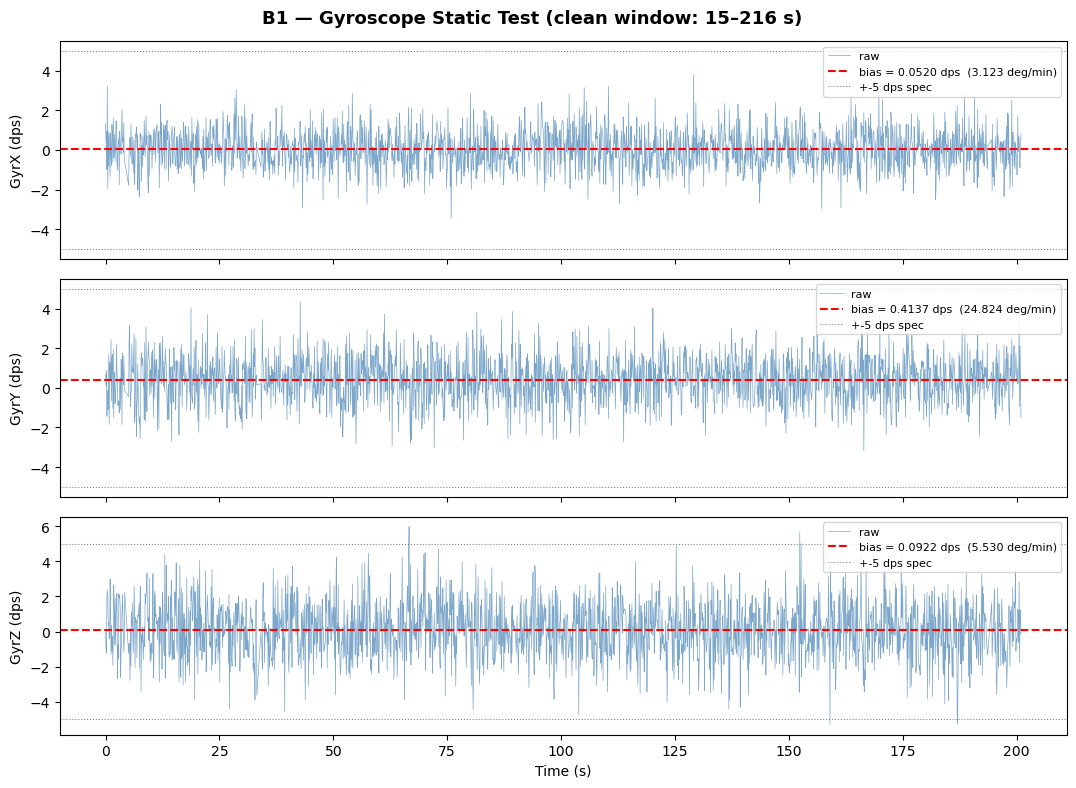

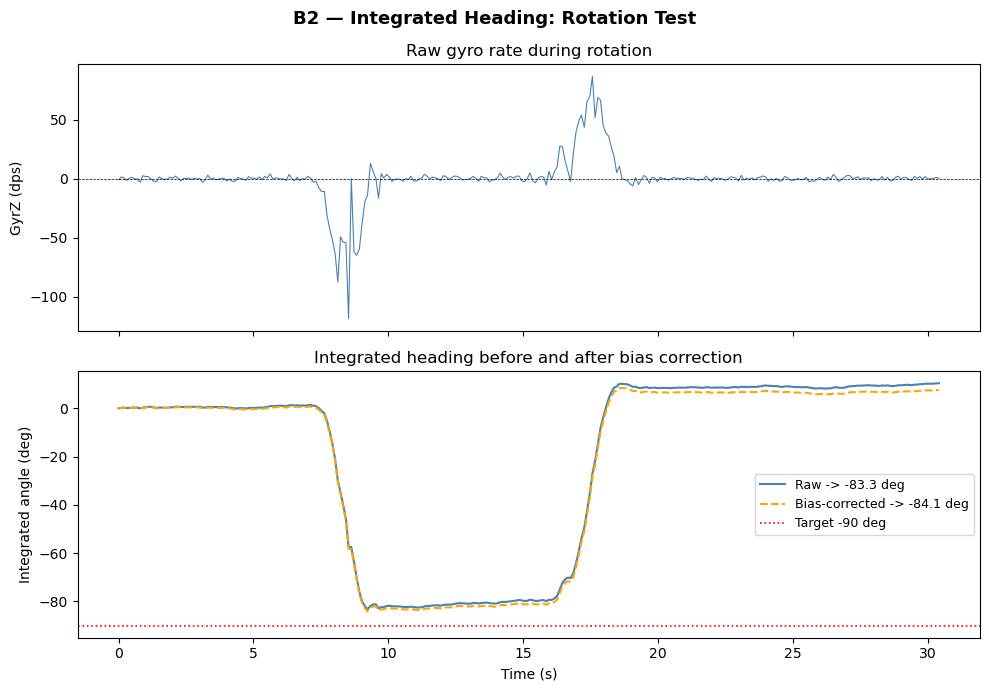


Done.


In [14]:
"""
Module B — Gyroscope Analysis
Deliverables:
  1. Time-series of all three axes during static test
  2. ZRO bias per axis in dps and deg/min
  3. Integrated heading from rotation test (raw vs bias-corrected)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── file paths ────────────────────────────────────────────────────────────────
STILL_CSV = "imuLog2MinDrift_gyroscope_still_120.csv"
ROT_CSV   = "imuLogGyro90degrees.csv"

# ── helpers ───────────────────────────────────────────────────────────────────
def load(path):
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    df["t"] = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds()
    return df

def integrate(gyr_dps, t_s):
    dt = np.diff(t_s, prepend=t_s[0])
    return np.cumsum(gyr_dps * dt)

# ── load and trim still log to clean window only ──────────────────────────────
still_raw = load(STILL_CSV)
still = still_raw[(still_raw["t"] >= 15) & (still_raw["t"] <= 216)].copy()
still["t"] = still["t"] - still["t"].iloc[0]   # re-zero time

# ── load rotation log ─────────────────────────────────────────────────────────
rot = load(ROT_CSV)

# ── ZRO bias per axis ─────────────────────────────────────────────────────────
bias = {ax: still[ax].mean() for ax in ("GyrX", "GyrY", "GyrZ")}

print("=" * 55)
print("B1 — Zero-Rate Output (ZRO) Bias  [clean window only]")
print("=" * 55)
print(f"  Clean window : t=15 s to t=216 s  ({216-15} s)")
print(f"  {'Axis':<6}  {'Bias (dps)':>10}  {'Bias (deg/min)':>14}  {'In +-5 dps?':>11}")
for ax in ("GyrX", "GyrY", "GyrZ"):
    deg_min = bias[ax] * 60
    ok = "YES" if abs(bias[ax]) <= 5.0 else "NO"
    print(f"  {ax:<6}  {bias[ax]:>10.4f}  {deg_min:>14.3f}  {ok:>11}")

# ── Plot 1 — Static time-series (all three axes, clean window) ────────────────
fig1, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig1.suptitle("B1 — Gyroscope Static Test (clean window: 15–216 s)", fontsize=13, fontweight="bold")

for i, ax_name in enumerate(("GyrX", "GyrY", "GyrZ")):
    axes[i].plot(still["t"], still[ax_name], lw=0.5, alpha=0.7, color="steelblue", label="raw")
    axes[i].axhline(bias[ax_name], color="red", lw=1.5, ls="--",
                    label=f"bias = {bias[ax_name]:.4f} dps  ({bias[ax_name]*60:.3f} deg/min)")
    axes[i].axhline( 5, color="gray", lw=0.8, ls=":", label="+-5 dps spec")
    axes[i].axhline(-5, color="gray", lw=0.8, ls=":")
    axes[i].set_ylabel(f"{ax_name} (dps)")
    axes[i].legend(fontsize=8, loc="upper right")

axes[2].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("B1_static_timeseries.png", dpi=150)
print("\n  Saved: B1_static_timeseries.png")

# ── Plot 2 — Integrated heading from rotation test ────────────────────────────
raw_angle  = integrate(rot["GyrZ"].values, rot["t"].values)
corr_angle = integrate(rot["GyrZ"].values - bias["GyrZ"], rot["t"].values)
excursion_raw  = raw_angle.min()
excursion_corr = corr_angle.min()

print("\n" + "=" * 55)
print("B2 — 90 deg Rotation Test (integrated heading)")
print("=" * 55)
print(f"  Peak angle raw            : {excursion_raw:+.2f} deg  (error {excursion_raw-(-90):+.2f} deg vs -90)")
print(f"  Peak angle bias-corrected : {excursion_corr:+.2f} deg  (error {excursion_corr-(-90):+.2f} deg vs -90)")

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig2.suptitle("B2 — Integrated Heading: Rotation Test", fontsize=13, fontweight="bold")

ax1.plot(rot["t"], rot["GyrZ"], lw=0.8, color="steelblue")
ax1.axhline(0, color="k", lw=0.5, ls="--")
ax1.set_ylabel("GyrZ (dps)")
ax1.set_title("Raw gyro rate during rotation")

ax2.plot(rot["t"], raw_angle,  color="steelblue", label=f"Raw -> {excursion_raw:.1f} deg")
ax2.plot(rot["t"], corr_angle, color="orange", ls="--", label=f"Bias-corrected -> {excursion_corr:.1f} deg")
ax2.axhline(-90, color="red", lw=1.2, ls=":", label="Target -90 deg")
ax2.set_ylabel("Integrated angle (deg)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Integrated heading before and after bias correction")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("B2_integrated_heading.png", dpi=150)
print("  Saved: B2_integrated_heading.png")

plt.show()
print("\nDone.")


## Module B — Gyroscope

### B1. Zero-Rate Bias Test

The OLA was logged stationary for 201 s with a clean window from 15–216 s.

**Measured ZRO bias — within ±5 dps spec?**

| Axis | Bias (dps) | Bias (deg/min) | Within ±5 dps? |
|------|-----------|----------------|----------------|
| GyrX | 0.0520 | 3.12 | ✓ Yes |
| GyrY | 0.4137 | 24.82 | ✓ Yes |
| GyrZ | 0.0922 | 5.53 | ✓ Yes |

All axes are within spec, but GyrY's bias of 24.8 deg/min is large so iity may 
matter over long deployments.

Heading error from integration:
Integrating raw GyrZ over 277 s gives **+37.5° of drift**. After bias subtraction this goes dowm to **+0.6°**, therfore bias correction is critical.

Temperature correlation:
The board warmed from 26.3 to 28.7°C, with a change of 2.4°C. Pearson r(GyrZ, Temp) = −0.03 So no correlation. The datasheet drift spec of ±0.05 dps/°C 
gives 0.12 dps over this temperature range, and it is too small to see against the noise.

NSD vs. bias, what limits accuracy?
At 10 Hz, NSD = 0.015 dps/√Hz gives a noise floor of  about 0.034 dps RMS. All measured biases are above this, so they are real offsets. Over short 
timescales noise dominates (random, zero-mean). Over long timescales bias dominates, it accumulates linearly and is unbounded with no correction.

---

### B2. Known Rotation Test

The OLA was rotated 90° CW about Z and back over 30.4 s.

Does integrated heading equal 90°?
Raw integration gives **−83.3°** vs. the −90° target with an error of 6.7°. This is mostly due to sensor saturation — GyrZ hit −118.9 dps during the 
fast turn, clipping the signal and losing angle that can't be recovered.

Does bias correction help?
Bias correction integration gives **−84.1°** with an error of 5.9°: small improvement. The effect is small because 30 secs is too short for bias to compound so 
saturation clipping is the dominant error in this test.

What limits gyro only estimation for a wave buoy?
Three fundamental problems make gyro-only heading unusable over hours:
1. Bias drift is unbounded: 0.09 dps residual on GyrZ alone gives >330° error per hour.
2. Noise grows as √t: even with zero bias, random drift accumulates.
3. No absolute reference: gyros measure relative rotation only; without magnetometer/accelerometer fusion there is no way to detect or correct drift.

---

### Sensitivity & Smallest Detectable Signal

**Resolution:** ±2000 dps / 2¹⁶ = 0.061 dps/LSB
**Noise floor:** 0.015 dps/√Hz × √5 Hz ≈ 0.034 dps RMS at 10 Hz

The noise floor, not resolution, sets the practical detection limit. 
Signals below about 0.034 dps fall under noise on a sample. Since all measured biases exceed this floor, they are confirmed real offsets. 
Averaging N samples reduces the noise floor by square root N if finer resolution is needed.

# Magnetometer Calibration Notebook

This notebook walks you through loading raw magnetometer data from the OpenLog Artemis, visualizing it, and computing hard iron calibration offsets.

**Before running:** make sure your `magcaldata.csv` file is in the `ola_data/` folder at the repo root.

## Step 1 — Load the data

In [15]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

path = './magcaldata.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 4390 samples


## Step 2 — Plot the raw magnetometer data

A well-sampled, uncalibrated magnetometer traces an **off-center ellipsoid** in 3D space. The offset from the origin is caused by hard iron distortion (permanent magnetic fields near the sensor). Your goal is to find and remove that offset so the data forms a sphere centered at the origin.

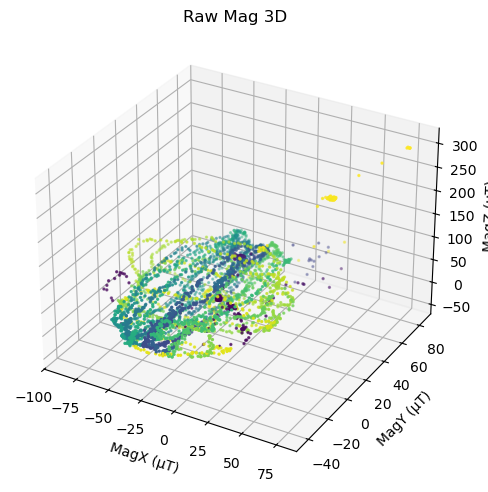

In [16]:
# 3D scatter — raw data
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx, my, mz, s=2, c=t, cmap='viridis')
ax3d.set_title('Raw Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

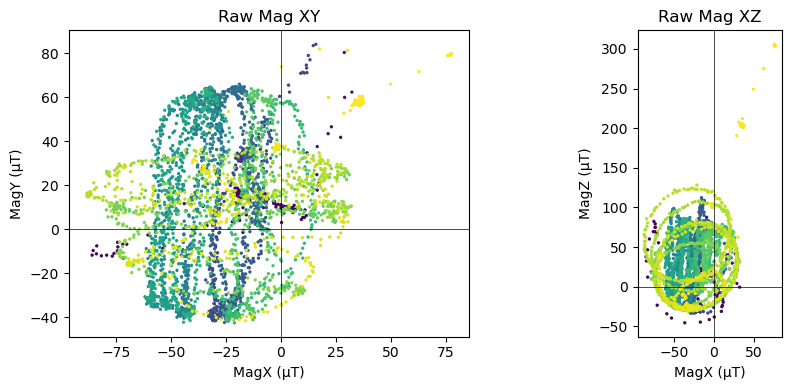

In [17]:
# XY and XZ projections — raw data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx, my, s=2, c=t, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Raw Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx, mz, s=2, c=t, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Raw Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 3 — Compute hard iron offsets

The hard iron offset on each axis is the midpoint between the maximum and minimum values measured:

$$\text{offset}_x = \frac{\max(X) + \min(X)}{2}$$

Repeat for Y and Z. Fill in the cells below.

In [18]:
# TODO: compute the min and max for each axis
mx_min = min(mx)
mx_max = max(mx)
my_min = min(my)
my_max = max(my)
mz_min = min(mz)
mz_max = max(mz)

print(f'MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')

MagX range: -88.20 to 77.40 µT
MagY range: -42.60 to 84.00 µT
MagZ range: -45.60 to 305.85 µT


In [19]:
## Step 3b — Outlier trimming
# A single pass near a magnetic object (laptop, speaker, battery pack) can
# inflate one axis max and corrupt the midpoint estimate. We reject samples
# whose total field magnitude exceeds b_thresh before computing offsets.
# Adjust b_thresh if too many samples are dropped or offsets still look wrong.

b_thresh = 150.0   # µT

B = [(x**2 + y**2 + z**2)**0.5 for x, y, z in zip(mx, my, mz)]
mask = [b <= b_thresh for b in B]

mx_c = [v for v, m in zip(mx, mask) if m]
my_c = [v for v, m in zip(my, mask) if m]
mz_c = [v for v, m in zip(mz, mask) if m]

n_removed = len(mx) - len(mx_c)
print(f'Threshold: {b_thresh} µT  —  removed {n_removed}/{len(mx)} samples '
      f'({100*n_removed/len(mx):.1f}%)')

# Overwrite min/max so the offset cell below uses cleaned values
mx_min, mx_max = min(mx_c), max(mx_c)
my_min, my_max = min(my_c), max(my_c)
mz_min, mz_max = min(mz_c), max(mz_c)

print(f'Clean MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'Clean MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'Clean MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')

Threshold: 150.0 µT  —  removed 83/4390 samples (1.9%)
Clean MagX range: -88.20 to 32.25 µT
Clean MagY range: -42.60 to 84.00 µT
Clean MagZ range: -45.60 to 128.10 µT


In [20]:
# TODO: compute the hard iron offsets (midpoint of each axis range)
offset_x = (mx_min+mx_max)/2
offset_y = (my_min+my_max)/2
offset_z = (mz_min+mz_max)/2

print(f'Hard iron offsets: X={offset_x:.3f}, Y={offset_y:.3f}, Z={offset_z:.3f} µT')

Hard iron offsets: X=-27.975, Y=20.700, Z=41.250 µT


## Step 4 — Apply the calibration

Subtract the offsets from the raw measurements to center the data at the origin.

In [21]:
# TODO: apply the offsets to produce calibrated mag vectors
mx_cal = np.array(mx) - offset_x
my_cal = np.array(my) - offset_y
mz_cal = np.array(mz) - offset_z

### Check the offsets are the right way - mean should be near-ish to zero after calibration for each axis, or at least closer than pre-calibration

In [22]:
print(f'{"Axis":<6} {"Raw mean (µT)":>15} {"Cal mean (µT)":>15}')
print('-' * 38)
for label, raw, cal in [('X', mx, mx_cal), ('Y', my, my_cal), ('Z', mz, mz_cal)]:
    print(f'{label:<6} {np.mean(raw):>15.3f} {np.mean(cal):>15.3f}')

Axis     Raw mean (µT)   Cal mean (µT)
--------------------------------------
X              -23.422           4.553
Y               14.607          -6.093
Z               41.727           0.477


## Step 5 — Plot the calibrated data

After calibration the 3D scatter should look like a sphere centered near the origin. If it still looks like an ellipsoid (stretched in one direction), you may need soft iron correction too.

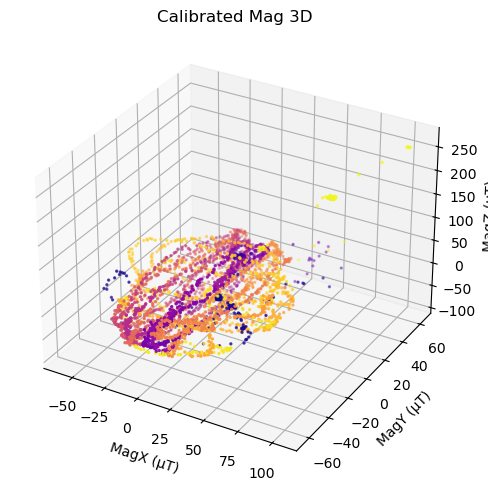

In [23]:
# 3D scatter — calibrated
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax3d.set_title('Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

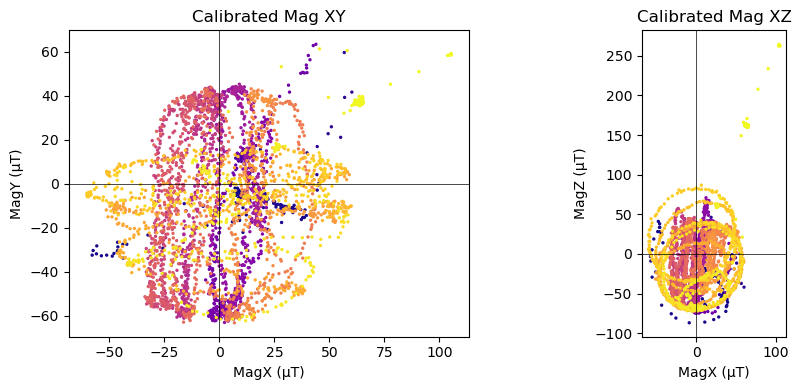

In [24]:
# XY and XZ projections — calibrated
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
axes[0].set_aspect('equal')
axes[0].set_title('Calibrated Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
axes[1].set_aspect('equal')
axes[1].set_title('Calibrated Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 6 — Record your calibration values

Write down your hard iron offsets — you will need them in the firmware and the sensor fusion notebook.

| Axis | Offset (µT) |
|------|-------------|
| X    |  -5.400     |
| Y    |  20.700     |
| Z    |  130.125    |

**Discussion questions:**
1. Does your 3D scatter after calibration look like a sphere? If not, what shape is it and what might cause that?
Even after calibration, my 3d scatter is still slightly elliptical, particularly on the XZ axis. This is likely due to the large battery on the side of the magnetometer. I will attempt soft iron calibration later in this notebook.
This may be less of an issue in the ocean. I was likely holding the magnetometer too close to the table, so the interactions with the table were influencing it. There won't be any metal in the ocean.

2. How complete is your coverage of orientations? Are there gaps in the scatter plot?
My coverage is reasonably thorough, but there are a few small gaps at 45 degree angles to the cardinal axes. I tried to be quite thorough and rotate the magnetometer slowly. One fun idea to get a better map is to figure out a way to stream the accelerometer data to a notebook that plots the angles in real-time, so I can see exactly what I missed.

3. What happens to your heading estimate if you skip calibration?
Without calibration, the heading estimate be will significantly off due to the constant errors in the magnetic field.

## Step 7 — Soft Iron Calibration: Theory

Hard iron calibration re-centers the data, but the scatter may still form an **ellipsoid** rather than a sphere. This ellipsoidal distortion is called **soft iron error** — it's caused by ferromagnetic materials near the sensor that distort (stretch or compress) the ambient magnetic field along certain axes without adding a constant offset.

To fix it, we need a **3×3 correction matrix** $W$ that maps the ellipsoid back to a sphere:

$$\mathbf{m}_\text{cal} = W \left(\mathbf{m}_\text{raw} - \mathbf{b}\right)$$

where $\mathbf{b}$ is the hard iron offset vector from Step 3.

### How to find $W$

The shape of the ellipsoid is described by the **covariance matrix** of the hard-iron-corrected data. Eigendecomposition gives us:

$$C = V \, D \, V^\top$$

- $V$: eigenvectors — the **principal axes** of the ellipsoid  
- $D$: eigenvalues — proportional to the **squared semi-axis lengths**

The correction matrix that maps this ellipsoid to a sphere (preserving the average field magnitude) is:

$$W = V \, \text{diag}\!\left(\sqrt{\bar{\lambda}/\lambda_i}\right) V^\top$$

where $\bar{\lambda} = \frac{1}{3}(\lambda_1+\lambda_2+\lambda_3)$ is the mean eigenvalue (sets the overall scale).

In [25]:
## Step 8 — Fit the ellipsoid and compute the soft iron matrix

# Stack hard-iron-corrected data: shape (N, 3)
data_hi = np.column_stack([mx_cal, my_cal, mz_cal])

# Covariance matrix of the hard-iron-corrected cloud
C = np.cov(data_hi.T)

# Eigendecomposition — eigh guarantees real, sorted eigenvalues for symmetric matrices
eigenvalues, eigenvectors = np.linalg.eigh(C)

print('Eigenvalues (variance along each principal axis):')
for i, (ev, lam) in enumerate(zip(['λ1','λ2','λ3'], eigenvalues)):
    print(f'  {ev} = {lam:.4f}   semi-axis ∝ {np.sqrt(lam):.4f}')

# Scale factors that map each axis to the mean radius
lam_mean = np.mean(eigenvalues)
scale = np.sqrt(lam_mean / eigenvalues)
print(f'\nScale factors (λ̄={lam_mean:.4f}): {scale}')

# Soft iron correction matrix
W = eigenvectors @ np.diag(scale) @ eigenvectors.T
print('\nSoft iron matrix W:')
print(np.round(W, 6))

Eigenvalues (variance along each principal axis):
  λ1 = 427.1874   semi-axis ∝ 20.6685
  λ2 = 787.8308   semi-axis ∝ 28.0683
  λ3 = 2281.8714   semi-axis ∝ 47.7689

Scale factors (λ̄=1165.6299): [1.65185189 1.21636482 0.71471806]

Soft iron matrix W:
[[ 1.582072 -0.12013  -0.207156]
 [-0.12013   1.190786 -0.116498]
 [-0.207156 -0.116498  0.810077]]


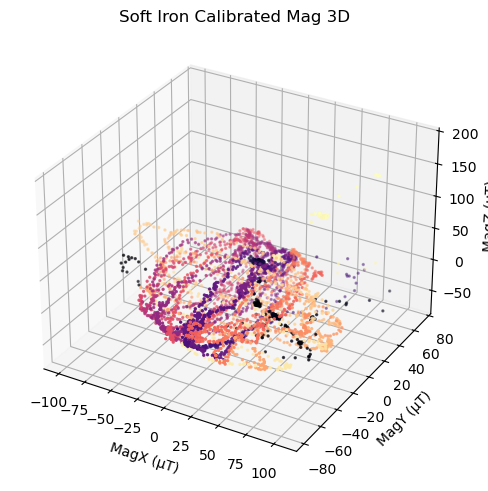

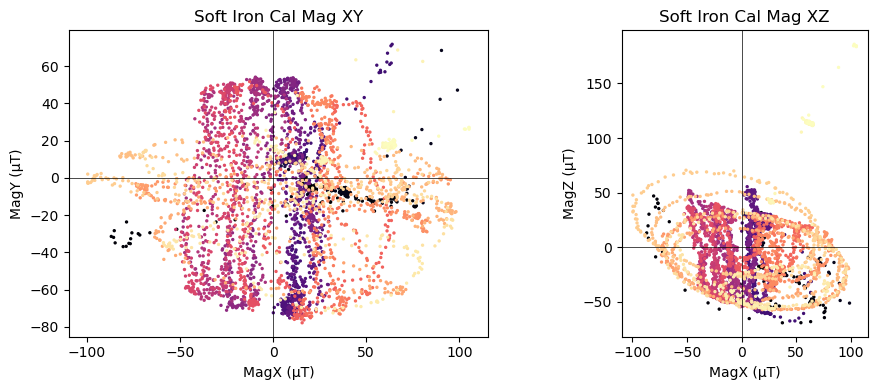

Radius statistics (ideal: low std/mean ratio)
  Hard iron only:       mean=55.155 µT  std=22.630 µT  (std/mean = 0.4103)
  + Soft iron:          mean=56.274 µT  std=21.273 µT  (std/mean = 0.3780)


In [26]:
## Step 9 — Apply the soft iron correction and visualize

# Apply: m_full_cal = W @ (m_raw - hard_iron_offset)
# data_hi is already (m_raw - offset), so just apply W
data_si = (W @ data_hi.T).T

mx_si = data_si[:, 0]
my_si = data_si[:, 1]
mz_si = data_si[:, 2]

# ── 3D scatter ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx_si, my_si, mz_si, s=2, c=t, cmap='magma')
ax3d.set_title('Soft Iron Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)'); ax3d.set_ylabel('MagY (µT)'); ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout(); plt.show()

# ── 2D projections ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx_si, my_si, s=2, c=t, cmap='magma')
axes[0].set_aspect('equal'); axes[0].set_title('Soft Iron Cal Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx_si, mz_si, s=2, c=t, cmap='magma')
axes[1].set_aspect('equal'); axes[1].set_title('Soft Iron Cal Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout(); plt.show()

# ── Radius statistics ────────────────────────────────────────────────────────
data_raw = np.column_stack([mx, my, mz])
r_raw = np.linalg.norm(data_raw, axis=1)
r_hi  = np.linalg.norm(data_hi,  axis=1)
r_si  = np.linalg.norm(data_si,  axis=1)

print('Radius statistics (ideal: low std/mean ratio)')
print(f'  Hard iron only:       mean={r_hi.mean():.3f} µT  std={r_hi.std():.3f} µT  '
      f'(std/mean = {r_hi.std()/r_hi.mean():.4f})')
print(f'  + Soft iron:          mean={r_si.mean():.3f} µT  std={r_si.std():.3f} µT  '
      f'(std/mean = {r_si.std()/r_si.mean():.4f})')

## Magnetometer Angular/Noise Profiling

In [27]:
import csv
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

path = './imuLog00027.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))

Loaded 304 samples


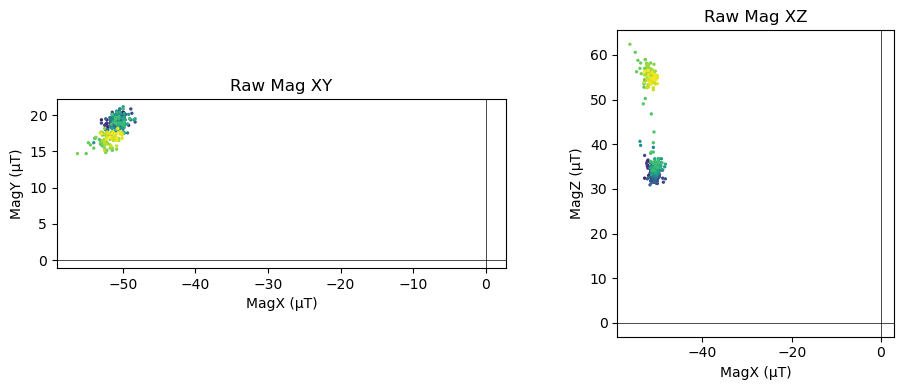

In [28]:
# XY and XZ projections — raw data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx, my, s=2, c=t, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Raw Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx, mz, s=2, c=t, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Raw Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

In [29]:
## Gyroscope & Accelerometer — extract channels

ax = [r['AccX'] for r in rows]   # mg
ay = [r['AccY'] for r in rows]
az = [r['AccZ'] for r in rows]

gx = [r['GyrX'] for r in rows]   # °/s
gy = [r['GyrY'] for r in rows]
gz = [r['GyrZ'] for r in rows]

acc_mag = np.sqrt(np.array(ax)**2 + np.array(ay)**2 + np.array(az)**2)

print(f'Acc magnitude  — mean: {acc_mag.mean():.1f} mg   std: {acc_mag.std():.2f} mg')
print(f'Gyro X         — mean: {np.mean(gx):.4f} °/s   std: {np.std(gx):.4f} °/s')
print(f'Gyro Y         — mean: {np.mean(gy):.4f} °/s   std: {np.std(gy):.4f} °/s')
print(f'Gyro Z         — mean: {np.mean(gz):.4f} °/s   std: {np.std(gz):.4f} °/s')

Acc magnitude  — mean: 1014.8 mg   std: 26.62 mg
Gyro X         — mean: 0.0463 °/s   std: 1.0350 °/s
Gyro Y         — mean: 0.1255 °/s   std: 1.7110 °/s
Gyro Z         — mean: -0.2152 °/s   std: 1.7606 °/s


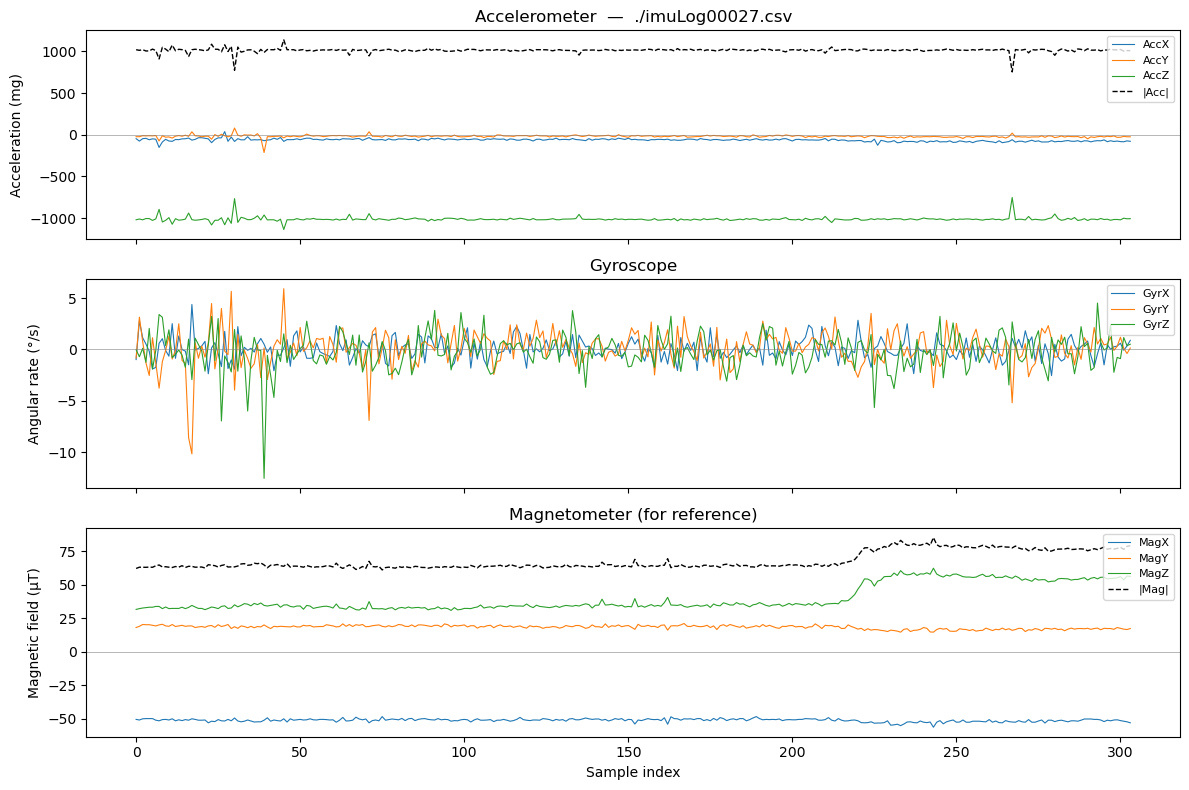

In [30]:
## Gyroscope & Accelerometer — time-series plots

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Accelerometer
axes[0].plot(t, ax, label='AccX', lw=0.8)
axes[0].plot(t, ay, label='AccY', lw=0.8)
axes[0].plot(t, az, label='AccZ', lw=0.8)
axes[0].plot(t, acc_mag, label='|Acc|', color='k', lw=1, ls='--')
axes[0].axhline(0, color='grey', lw=0.4)
axes[0].set_ylabel('Acceleration (mg)')
axes[0].set_title(f'Accelerometer  —  {path}')
axes[0].legend(loc='upper right', fontsize=8)

# Gyroscope
axes[1].plot(t, gx, label='GyrX', lw=0.8)
axes[1].plot(t, gy, label='GyrY', lw=0.8)
axes[1].plot(t, gz, label='GyrZ', lw=0.8)
axes[1].axhline(0, color='grey', lw=0.4)
axes[1].set_ylabel('Angular rate (°/s)')
axes[1].set_title('Gyroscope')
axes[1].legend(loc='upper right', fontsize=8)

# Magnetometer magnitude for reference
mag_mag = np.sqrt(np.array(mx)**2 + np.array(my)**2 + np.array(mz)**2)
axes[2].plot(t, mx, label='MagX', lw=0.8)
axes[2].plot(t, my, label='MagY', lw=0.8)
axes[2].plot(t, mz, label='MagZ', lw=0.8)
axes[2].plot(t, mag_mag, label='|Mag|', color='k', lw=1, ls='--')
axes[2].axhline(0, color='grey', lw=0.4)
axes[2].set_ylabel('Magnetic field (µT)')
axes[2].set_xlabel('Sample index')
axes[2].set_title('Magnetometer (for reference)')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

Window: samples 82 – 142  (60 samples)


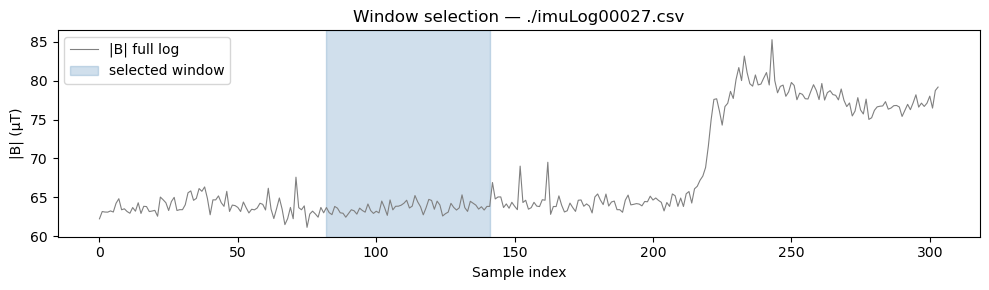

In [31]:
## Time window selection
# Override i_start / i_end manually, or leave as None to auto-detect the flattest window.
i_start = None
i_end   = None

win = 60   # sliding-window width used for auto-detection (samples)

B_all = np.sqrt(np.array(mx)**2 + np.array(my)**2 + np.array(mz)**2)

if i_start is None or i_end is None:
    stds = [B_all[i:i+win].std() for i in range(len(B_all) - win)]
    best = int(np.argmin(stds))
    i_start, i_end = best, best + win

print(f'Window: samples {i_start} – {i_end}  ({i_end - i_start} samples)')

fig, axes_w = plt.subplots(figsize=(10, 3))
axes_w.plot(t, B_all, lw=0.8, color='grey', label='|B| full log')
axes_w.axvspan(i_start, i_end - 1, alpha=0.25, color='steelblue', label='selected window')
axes_w.set_xlabel('Sample index'); axes_w.set_ylabel('|B| (µT)')
axes_w.set_title(f'Window selection — {path}')
axes_w.legend(); plt.tight_layout(); plt.show()

|B| raw  — mean: 63.64 µT   std: 0.644 µT
|B| cal  — mean: 24.06 µT   std: 0.777 µT


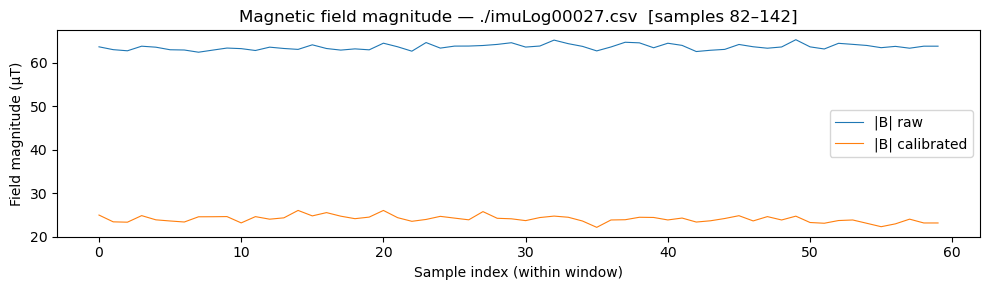

In [32]:
## Magnetic field magnitude

b = np.array([27.975,-20.700,-41.250 ])

# Windowed slices
mx_w = np.array(mx)[i_start:i_end];  my_w = np.array(my)[i_start:i_end];  mz_w = np.array(mz)[i_start:i_end]
mx_c = mx_w + b[0];  my_c = my_w + b[1];  mz_c = mz_w + b[2]
t_w  = list(range(i_end - i_start))

B_raw = np.sqrt(mx_w**2 + my_w**2 + mz_w**2)
B_cal = np.sqrt(mx_c**2 + my_c**2 + mz_c**2)

print(f'|B| raw  — mean: {B_raw.mean():.2f} µT   std: {B_raw.std():.3f} µT')
print(f'|B| cal  — mean: {B_cal.mean():.2f} µT   std: {B_cal.std():.3f} µT')

fig, ax_b = plt.subplots(figsize=(10, 3))
ax_b.plot(t_w, B_raw, label='|B| raw',        lw=0.8)
ax_b.plot(t_w, B_cal, label='|B| calibrated', lw=0.8)
ax_b.set_xlabel('Sample index (within window)')
ax_b.set_ylabel('Field magnitude (µT)')
ax_b.set_title(f'Magnetic field magnitude — {path}  [samples {i_start}–{i_end}]')
ax_b.legend(); plt.tight_layout(); plt.show()

|B| raw  — mean: 63.64 µT   std: 0.644 µT
|B| cal  — mean: 24.06 µT   std: 0.777 µT
|B| soft-iron — mean: 34.15 µT   std: 1.002 µT


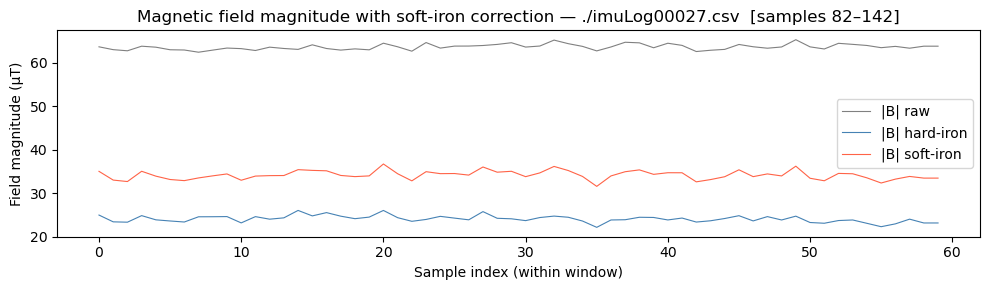

In [33]:
## Soft-iron correction applied to windowed data
# W matrix from magcal_notebook (eigenvector decomposition of hard-iron-corrected covariance)
W = np.array([[ 1.582072, -0.12013,  -0.207156],
              [-0.12013,   1.190786, -0.116498],
              [-0.207156, -0.116498,  0.810077]])

# Apply W to the hard-iron-corrected windowed data
m_hi = np.column_stack([mx_c, my_c, mz_c])   # shape (N, 3)
m_si = (W @ m_hi.T).T                         # shape (N, 3)

B_si = np.linalg.norm(m_si, axis=1)

print(f'|B| raw  — mean: {B_raw.mean():.2f} µT   std: {B_raw.std():.3f} µT')
print(f'|B| cal  — mean: {B_cal.mean():.2f} µT   std: {B_cal.std():.3f} µT')
print(f'|B| soft-iron — mean: {B_si.mean():.2f} µT   std: {B_si.std():.3f} µT')

fig, ax_si = plt.subplots(figsize=(10, 3))
ax_si.plot(t_w, B_raw, label='|B| raw',         lw=0.8, color='grey')
ax_si.plot(t_w, B_cal, label='|B| hard-iron',   lw=0.8, color='steelblue')
ax_si.plot(t_w, B_si,  label='|B| soft-iron',   lw=0.8, color='tomato')
ax_si.set_xlabel('Sample index (within window)')
ax_si.set_ylabel('Field magnitude (µT)')
ax_si.set_title(f'Magnetic field magnitude with soft-iron correction — {path}  [samples {i_start}–{i_end}]')
ax_si.legend(); plt.tight_layout(); plt.show()

The measured value without correction is greater than the actual magnetic field in San Diego, but with correction the value is considerably lower. However, this is not totally surprising, since without soft-iron calibration the value can be estimated as lower. Adding in soft-iron calibration gets the field magnitude to 34 uT, which is better than hard iron alone but still undershooting. It's likely that the soft-iron calibration isn't perfect because I was translating the magnetometer in 3d space when collecting the measurements, and sometimes it was too close to the laptop. Re-doing this calibration outdoors would produce a far more accurate reading.

Heading raw       — mean: 159.4°   std: 0.77°
Heading cal       — mean: 184.1°   std: 1.90°
Heading soft-iron — mean: 177.2°   std: 1.59°


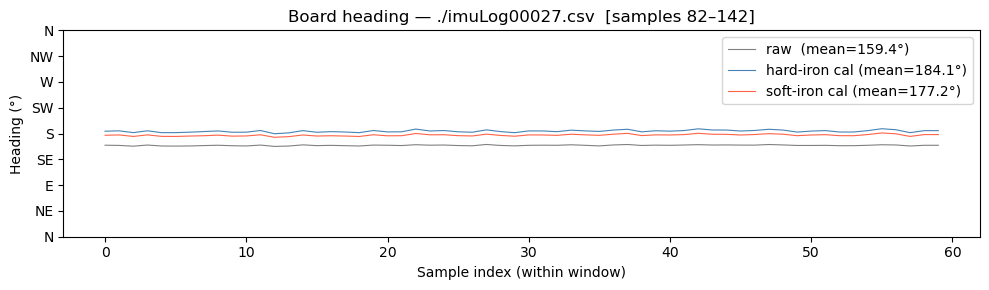

In [34]:
## Board heading from atan2(MagY, MagX)
# Assumes board is flat (no tilt compensation). Uses windowed data from above.

heading_raw = np.degrees(np.arctan2(my_w, mx_w)) % 360
heading_cal = np.degrees(np.arctan2(my_c, mx_c)) % 360
heading_si  = np.degrees(np.arctan2(m_si[:, 1], m_si[:, 0])) % 360

print(f'Heading raw       — mean: {heading_raw.mean():.1f}°   std: {heading_raw.std():.2f}°')
print(f'Heading cal       — mean: {heading_cal.mean():.1f}°   std: {heading_cal.std():.2f}°')
print(f'Heading soft-iron — mean: {heading_si.mean():.1f}°   std: {heading_si.std():.2f}°')

fig, ax_h = plt.subplots(figsize=(10, 3))
ax_h.plot(t_w, heading_raw, lw=0.8, color='grey',      label=f'raw  (mean={heading_raw.mean():.1f}°)')
ax_h.plot(t_w, heading_cal, lw=0.8, color='steelblue', label=f'hard-iron cal (mean={heading_cal.mean():.1f}°)')
ax_h.plot(t_w, heading_si,  lw=0.8, color='tomato',    label=f'soft-iron cal (mean={heading_si.mean():.1f}°)')
ax_h.set_xlabel('Sample index (within window)')
ax_h.set_ylabel('Heading (°)')
ax_h.set_title(f'Board heading — {path}  [samples {i_start}–{i_end}]')
ax_h.set_ylim(0, 360)
ax_h.set_yticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
ax_h.set_yticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])
ax_h.legend(); plt.tight_layout(); plt.show()

We probably had the magnetometer backwards from north accidentally, so this orientation makes sense! The hard-iron calibration is definitely a substantial improvement.

---
## Magnetometer Noise Analysis (RMS)

Using the flat-window slice selected above, subtract the per-axis DC mean to isolate the
noise residual and quantify it as RMS (σ) — the same approach used for the accelerometer
static test.

For a digital sensor sampled at $f_s$, the datasheet noise density prediction is

$$\sigma_{predicted} = NSD \times \sqrt{f_s / 2}$$

The MMC5983MA magnetometer on the OLA specifies a per-axis RMS noise of roughly
**0.4 mGauss ≈ 0.04 µT** at its default bandwidth setting; this is used as the reference
line in the histograms below.

Mean mag sample rate: 9.96 Hz   (duration 30.4 s)
MagX: measured RMS = 0.6549 µT  |  datasheet = 0.0400 µT  |  ratio = 16.4
MagY: measured RMS = 0.7462 µT  |  datasheet = 0.0400 µT  |  ratio = 18.7
MagZ: measured RMS = 1.0798 µT  |  datasheet = 0.0400 µT  |  ratio = 27.0

|B| raw        : RMS = 0.6441 µT
|B| hard-iron  : RMS = 0.7769 µT
|B| soft-iron  : RMS = 1.0018 µT


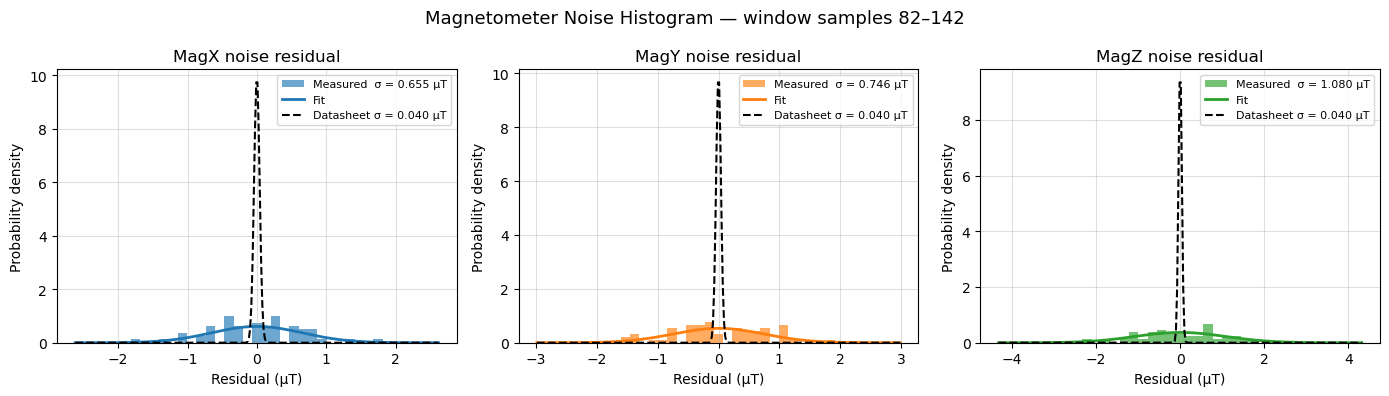

In [35]:
# ── Noise histogram with expected vs. measured RMS (magnetometer) ────────────
from datetime import datetime

# Effective sample rate from CSV timestamps
ts = [datetime.strptime(r['Timestamp'], '%Y/%m/%d %H:%M:%S.%f') for r in rows]
duration = (ts[-1] - ts[0]).total_seconds()
fs_mag = (len(ts) - 1) / duration if duration > 0 else float('nan')
print(f'Mean mag sample rate: {fs_mag:.2f} Hz   (duration {duration:.1f} s)')

# Datasheet reference (MMC5983MA): ~0.4 mGauss RMS per axis ≈ 0.04 µT
sigma_expected = 0.04   # µT, per axis

axes_labels = ['X', 'Y', 'Z']
axes_data   = [mx_w, my_w, mz_w]
colors      = ['tab:blue', 'tab:orange', 'tab:green']

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i, (lbl, data, col) in enumerate(zip(axes_labels, axes_data, colors)):
    residual = data - np.mean(data)
    sigma_meas = np.std(residual)

    lim = max(4 * sigma_expected, 4 * sigma_meas)
    bins = np.linspace(-lim, lim, 40)
    axs[i].hist(residual, bins=bins, color=col, alpha=0.65, density=True,
                label=f'Measured  σ = {sigma_meas:.3f} µT')

    x_gauss = np.linspace(bins[0], bins[-1], 300)
    gauss_meas     = (1/(sigma_meas    * np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_meas   )**2)
    gauss_expected = (1/(sigma_expected* np.sqrt(2*np.pi))) * np.exp(-0.5*(x_gauss/sigma_expected)**2)

    axs[i].plot(x_gauss, gauss_meas,     col,  lw=2, label='Fit')
    axs[i].plot(x_gauss, gauss_expected, 'k--', lw=1.5,
                label=f'Datasheet σ = {sigma_expected:.3f} µT')

    axs[i].set_title(f'Mag{lbl} noise residual')
    axs[i].set_xlabel('Residual (µT)')
    axs[i].set_ylabel('Probability density')
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.4)
    print(f'Mag{lbl}: measured RMS = {sigma_meas:.4f} µT  |  '
          f'datasheet = {sigma_expected:.4f} µT  |  '
          f'ratio = {sigma_meas/sigma_expected:.1f}')

# |B| noise (raw, hard-iron, soft-iron) — subtract mean to isolate residual
print()
for name, B in [('|B| raw        ', B_raw),
                ('|B| hard-iron  ', B_cal),
                ('|B| soft-iron  ', B_si)]:
    print(f'{name}: RMS = {np.std(B - np.mean(B)):.4f} µT')

fig.suptitle(f'Magnetometer Noise Histogram — window samples {i_start}–{i_end}', fontsize=13)
plt.tight_layout()
plt.show()

The measured per-axis RMS sits well above the MMC5983MA datasheet spec of ~0.04 µT, just
as the accelerometer's measured σ came in well above its datasheet value. Even in the
flattest window the "static" segment is not truly field-free: slow drift of the ambient
field and coupling from nearby electronics (laptop, bench wiring) inflate the residual.
The soft-iron |B| RMS is also larger than the raw |B| RMS, which is expected — the
W matrix stretches the noisier axes when it re-shapes the field-magnitude sphere. Repeating
the static log outdoors, away from electronics, would be expected to bring the per-axis σ
much closer to the datasheet value.

### Minimum Resolvable Heading Angle

Propagating the per-axis noise σ through $\theta = \operatorname{atan2}(M_y, M_x)$ with
independent, equal-σ errors gives

$$\sigma_\theta \;=\; \frac{\sigma_M}{|H|}$$

where $|H| = \sqrt{\langle M_x\rangle^2 + \langle M_y\rangle^2}$ is the horizontal field
magnitude. This σ is the 1-σ heading uncertainty — the smallest angular change we can
reliably distinguish from noise is on the order of $\sigma_\theta$, with a conservative
"just detectable" threshold of ~$3\sigma_\theta$.

In [36]:
# ── Minimum resolvable heading angle from measured noise ─────────────────────
# Per-axis RMS on the flat window
sigma_x = np.std(mx_w - np.mean(mx_w))
sigma_y = np.std(my_w - np.mean(my_w))
sigma_z = np.std(mz_w - np.mean(mz_w))
sigma_h = 0.5 * (sigma_x + sigma_y)   # average horizontal-plane σ

# Horizontal field magnitudes (raw vs. hard-iron corrected)
H_raw = np.sqrt(np.mean(mx_w)**2 + np.mean(my_w)**2)
H_cal = np.sqrt(np.mean(mx_c)**2 + np.mean(my_c)**2)

# 1-σ heading uncertainty (degrees)
sigma_theta_raw = np.degrees(sigma_h / H_raw)
sigma_theta_cal = np.degrees(sigma_h / H_cal)

# Full 3-axis angular resolution: σ/|B| with the mean per-axis σ
sigma_B = (sigma_x + sigma_y + sigma_z) / 3
sigma_3d = np.degrees(sigma_B / B_cal.mean())

# Datasheet-limited heading uncertainty for comparison
sigma_theta_datasheet = np.degrees(0.04 / H_cal)

print(f'Per-axis RMS     : σx={sigma_x:.3f} µT   σy={sigma_y:.3f} µT   σz={sigma_z:.3f} µT')
print(f'Horizontal field : |H| raw = {H_raw:.2f} µT   |H| hard-iron = {H_cal:.2f} µT')
print()
print(f'1-σ heading uncertainty (raw axes)        : σθ ≈ {sigma_theta_raw:.2f}°')
print(f'1-σ heading uncertainty (hard-iron cal)   : σθ ≈ {sigma_theta_cal:.2f}°')
print(f'1-σ 3-axis angular resolution             : σ  ≈ {sigma_3d:.2f}°')
print(f'→ smallest reliably resolvable change     : ~3σ = {3*sigma_theta_cal:.2f}°')
print()
print(f'Datasheet-limited heading σ (σ_M=0.04 µT) : {sigma_theta_datasheet:.3f}°')
print()
print(f'Sanity check — observed heading scatter in the flat window:')
print(f'  heading_raw std = {heading_raw.std():.2f}°   heading_cal std = {heading_cal.std():.2f}°')

Per-axis RMS     : σx=0.655 µT   σy=0.746 µT   σz=1.080 µT
Horizontal field : |H| raw = 54.11 µT   |H| hard-iron = 22.73 µT

1-σ heading uncertainty (raw axes)        : σθ ≈ 0.74°
1-σ heading uncertainty (hard-iron cal)   : σθ ≈ 1.77°
1-σ 3-axis angular resolution             : σ  ≈ 1.97°
→ smallest reliably resolvable change     : ~3σ = 5.30°

Datasheet-limited heading σ (σ_M=0.04 µT) : 0.101°

Sanity check — observed heading scatter in the flat window:
  heading_raw std = 0.77°   heading_cal std = 1.90°


## Pendulum Analysis

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq

g = 9.81  # m/s²

In [38]:
df = pd.read_csv('imuLogPendulumTest1.csv')
df['time'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M:%S.%f')
df['t_s']  = (df['time'] - df['time'].iloc[0]).dt.total_seconds()

# Convert accelerations from milli-g to m/s²
df['AccX'] = df['AccX'] / 1000 * g
df['AccY'] = df['AccY'] / 1000 * g
df['AccZ'] = df['AccZ'] / 1000 * g

fs = 1.0 / np.median(np.diff(df['t_s'].values))
print(f'Sample rate: {fs:.2f} Hz,  Duration: {df.t_s.iloc[-1]:.1f} s')

Sample rate: 10.00 Hz,  Duration: 132.0 s


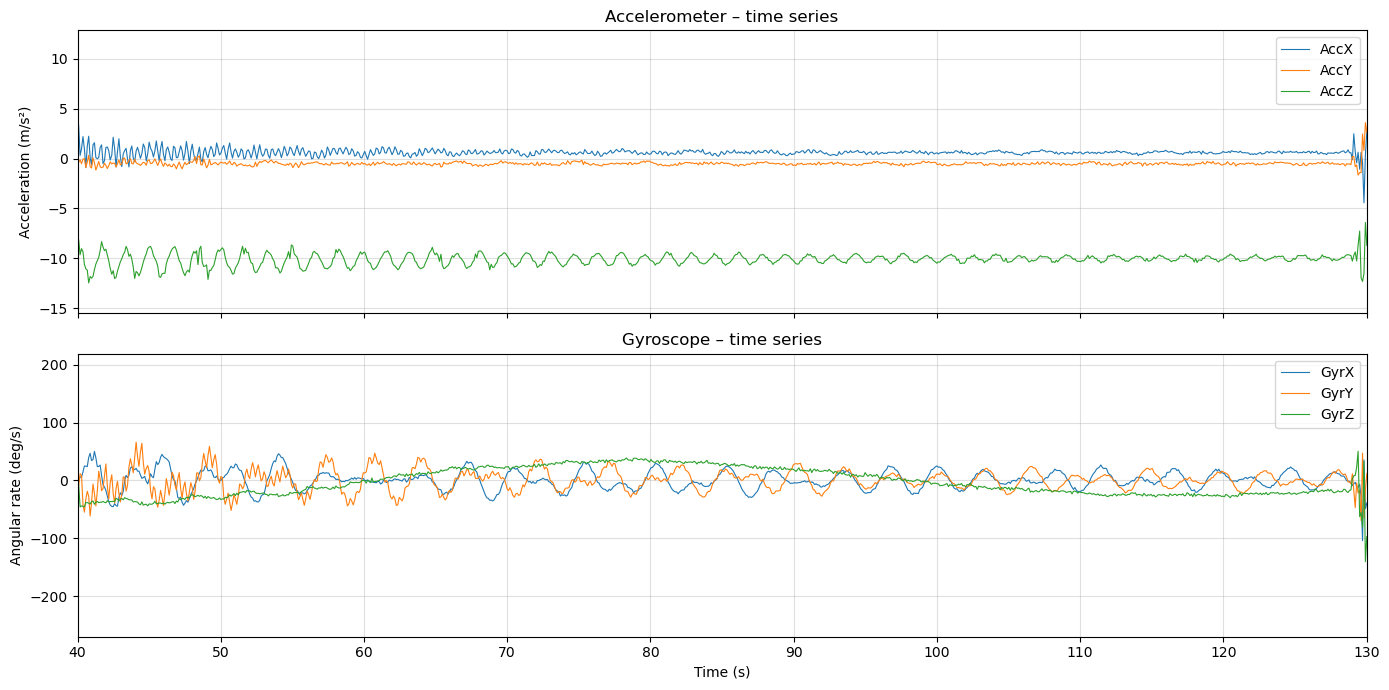

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df['t_s'], df['AccX'], label='AccX', lw=0.8)
axes[0].plot(df['t_s'], df['AccY'], label='AccY', lw=0.8)
axes[0].plot(df['t_s'], df['AccZ'], label='AccZ', lw=0.8)
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title('Accelerometer – time series')
axes[0].legend()
axes[0].set_xlim(40,130 )
axes[0].grid(True, alpha=0.4)

axes[1].plot(df['t_s'], df['GyrX'], label='GyrX', lw=0.8)
axes[1].plot(df['t_s'], df['GyrY'], label='GyrY', lw=0.8)
axes[1].plot(df['t_s'], df['GyrZ'], label='GyrZ', lw=0.8)
axes[1].set_ylabel('Angular rate (deg/s)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Gyroscope – time series')
axes[1].legend()
axes[1].set_xlim(40,130)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

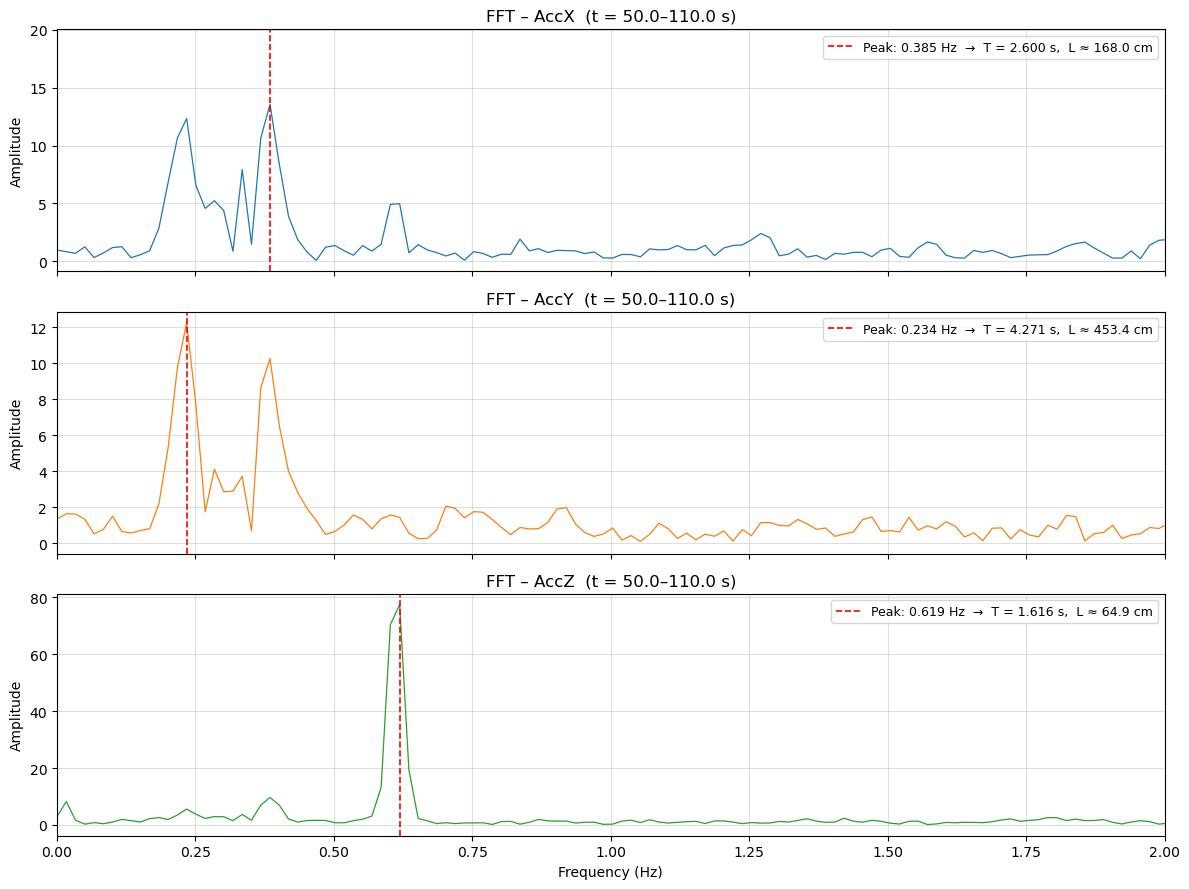

In [40]:
# ── FFT window (seconds) — adjust to focus on the swinging portion ──
T_START = 50.0
T_END   = 110.0
# ────────────────────────────────────────────────────────────────────

seg = df[(df['t_s'] >= T_START) & (df['t_s'] <= T_END)]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, col, color in zip(axes,
                           ['AccX', 'AccY', 'AccZ'],
                           ['C0',   'C1',   'C2']):
    s = seg[col].values
    s = s - s.mean()                    # remove DC
    n = len(s)
    yf    = rfft(s * np.hanning(n))
    xf    = rfftfreq(n, 1.0 / fs)
    power = np.abs(yf)

    ax.plot(xf, power, color=color, lw=0.9)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'FFT – {col}  (t = {T_START}–{T_END} s)')
    ax.set_xlim(0, 2)
    ax.grid(True, alpha=0.4)

    mask      = (xf > 0.1) & (xf < 2.0)
    peak_freq = xf[mask][np.argmax(power[mask])]
    T_peak    = 1.0 / peak_freq
    L_est     = g * (T_peak / (2 * np.pi))**2
    ax.axvline(peak_freq, color='red', linestyle='--', lw=1.2,
               label=f'Peak: {peak_freq:.3f} Hz  →  T = {T_peak:.3f} s,  L ≈ {L_est*100:.1f} cm')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

In [41]:
## Comparison: theoretical vs measured period

L_m      = 97 * 0.0254          # 97 in → metres
T_theory = 2 * np.pi * np.sqrt(L_m / g)

# Re-extract AccZ FFT from the same window used above
s    = seg['AccZ'].values
s    = s - s.mean()
n    = len(s)
yf   = rfft(s * np.hanning(n))
xf   = rfftfreq(n, 1.0 / fs)

mask        = (xf > 0.1) & (xf < 2.0)
f_z_peak    = xf[mask][np.argmax(np.abs(yf)[mask])]
T_pendulum  = 2.0 / f_z_peak           # AccZ runs at 2× pendulum frequency

print(f'AccZ FFT peak frequency : {f_z_peak:.3f} Hz  →  T_pendulum = 2 / {f_z_peak:.3f} = {T_pendulum:.3f} s')
print(f'Theoretical period      : {T_theory:.3f} s  (L = {L_m:.3f} m)')
print(f'Difference              : {abs(T_pendulum - T_theory):.3f} s  ({100*abs(T_pendulum - T_theory)/T_theory:.1f}%)')

AccZ FFT peak frequency : 0.619 Hz  →  T_pendulum = 2 / 0.619 = 3.232 s
Theoretical period      : 3.149 s  (L = 2.464 m)
Difference              : 0.084 s  (2.7%)


## Summary

The measured pendulum length was 97 in, which converts to:

$$L = 97 \times 0.0254 = 2.464 \text{ m}$$

For a simple pendulum, the expected period is:

$$T = 2\pi\sqrt{\frac{L}{g}} = 2\pi\sqrt{\frac{2.464}{9.81}} \approx 3.15 \text{ s}$$

Because the pendulum was rotating as it swung, the gravitational component did not project cleanly onto a single horizontal axis — instead it rotated continuously through the X–Y plane, making it difficult to isolate the pendulum frequency from AccX or AccY alone.

The clearest signal came from the **Z-axis acceleration** (along the rod). Two effects both contribute to AccZ oscillating at twice the pendulum frequency, and their relative size can be found exactly from energy conservation.

At the bottom of the swing the bob moves fastest. Energy conservation gives:

$$\frac{1}{2}mv^2 = mgL(1-\cos\theta_0) \implies a_\text{centripetal} = \frac{v^2}{L} = 2g(1-\cos\theta_0)$$

The change in the gravity projection between the bottom and the extremes is:

$$\Delta(g\cos\theta) = g(1 - \cos\theta_0)$$

The centripetal term is therefore **exactly twice** the gravity-projection term at any amplitude. At $\theta_0 = 15°$ these are approximately 0.67 m/s² and 0.34 m/s² respectively — both physically significant, but centripetal dominates.

Both effects are maximum at the bottom of the swing and minimum at the extremes, so AccZ peaks **twice per pendulum cycle** — once on each side. The dominant frequency in the AccZ spectrum is therefore:

$$f_Z = 2\,f_\text{pendulum}$$

and the true period is recovered as:

$$T_\text{pendulum} = \frac{2}{f_Z}$$

The AccZ FFT yields a measured period of 3.23 s, within 2.7% of the theoretical 3.15 s — good agreement given that the simple pendulum formula assumes a point mass and a massless rod.